<a href="https://colab.research.google.com/github/pneuma0/tech-challenge-olist/blob/main/Tech_Challenge_I_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kagglehub
import os

# Entendedo a base de dados
O dataset se chama [*Brazilian E-Commerce Public Dataset by Olist*](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data?select=olist_order_items_dataset.csv) e engloba um conjunto de quase 100.000 vendas realizadas de 2016 a 2018 em vários marketplaces no Brasil através da Olist.

## O que é Olist?
A Olist é uma empresa de intermediação que facilita a publicação de produtos em multiplos marketplaces e a gestão do processo de vendas e logística de entrega para todo o Brasil. Através da Olist, o usuário é capaz de administrar várias empresas em um unico lugar, transformando a Olist em um hub centralizador.

### Modelo de Negócio da Olist
O modelo de negócio se baseia em rentabilidade mista. Parte da receita do negócio vem da mensalidade paga por três planos com níveis diferentes de funcionalidade e outra parte vem de taxas por uso de serviços pay-as-you-go.

Os planos oferecidos, do mais caro para o mais barato, são:
- Avance
- Construa
- Impulsione
- Domine

As taxas de serviço pay-as-you-go são cobradas pelos serviços abaixo, sendo que a porcentagem ou valor variam de acordo com o plano:
- Link Pagamento
- Maquininha no Celular
- Cobrança Boleto
- Cobrança Pix QR Code

## Quais tipos de dados estão presentes no dataset?
Os dados englobam várias características das vendas e vão desde o valor da compra unitária, até as coordenadas de localização de cada compra.
Os dados estão divididos em 8 planilhas, sendo elas:
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv

## Pergunta norteadora e investigação principal
_Quais categorias de produtos possuem o melhor equilíbrio entre volume de vendas e satisfação do cliente, e como a logística influencia o sucesso dessas categorias?_

In [2]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Arquivos presentes no dataset:", os.listdir(path))
print("Caminho para os arquivos:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Arquivos presentes no dataset: ['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']
Caminho para os arquivos: /kaggle/input/brazilian-ecommerce


In [3]:
# Carregando os datasets

caminho = "/kaggle/input/brazilian-ecommerce/"

df_customers = pd.read_csv(caminho + 'olist_customers_dataset.csv')
df_sellers = pd.read_csv(caminho + 'olist_sellers_dataset.csv')
df_reviews = pd.read_csv(caminho + 'olist_order_reviews_dataset.csv')
df_items = pd.read_csv(caminho + 'olist_order_items_dataset.csv')
df_geolocation = pd.read_csv(caminho + 'olist_geolocation_dataset.csv')
df_category = pd.read_csv(caminho + 'product_category_name_translation.csv')
df_orders = pd.read_csv(caminho + 'olist_orders_dataset.csv')
df_payments = pd.read_csv(caminho + 'olist_order_payments_dataset.csv')
df_products = pd.read_csv(caminho + 'olist_products_dataset.csv')

# Coração do Dataset
Segundo os próprios responsáveis pela publicação do Dataset, a planilha olist_orders_dataset.csv é o coração que liga todas as outras informações. É possível integrar e explorar cada planilha a partir dela, então vamos começar por ela.

In [4]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
df_orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


### Composição da planilha de compras
A planilha é composta de 8 colunas, sendo elas:
- order_id
- customer_id
- order_status
- timestamps de compra, aprovação de compra, envio, entrega e estimativa de entrega

Verificando os valores nulos em cada coluna, é possível observar que existem pedidos que foram comprados, porém ainda não foram aprovados, ou ainda estão em trânsito.
- Pedidos ainda não aprovados: 160
- Pedidos não enviados: 1783
- Pedidos com transportadora e não entregues: 2965

In [6]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
df_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [8]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [10]:
df_items[df_items.duplicated(subset=['order_id'],keep=False)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


In [11]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [12]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Olhando as três planilhas ligadas pela chave _order_id_ ao dataset _df_orders_, é possível verificar as seguintes informações:
- Usuários podem usar mais de uma forma de pagamento em um mesmo pedido. É possível atestar isso pelas informações do próprio site da Olist.
- Algumas compras levaram mais de um item.
- Nem todas as compras possuem reviews.
Essas informações estão presentes também na explicação do dataset no Kaggle.

In [13]:
# Verificando duplicatas reais (linhas inteiras repetidas)
print(df_payments.duplicated().sum())
print(df_orders.duplicated().sum())
print(df_items.duplicated().sum())
print(df_reviews.duplicated().sum())

0
0
0
0


In [14]:
# Verificando se a Chave Primária é realmente única onde deveria ser
# Em df_orders, isso deve ser igual ao número total de linhas
print(df_orders['order_id'].nunique())

99441


In [15]:
# Detalhando nulidades (especialmente em reviews)
print(df_reviews.isnull().sum())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [16]:
repetidos = df_reviews['order_id'].duplicated().sum()
print(f"Pedidos com mais de uma avaliação: {repetidos}")

Pedidos com mais de uma avaliação: 551


In [17]:
df_reviews[df_reviews.duplicated(subset=['order_id'],keep=False)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
30,540e7bbb2d06cfb7f85f3a88ba7ac97f,cf73e2cb1f4a9480ed70c154da3d954a,5,NaN,NaN,2018-01-18 00:00:00,2018-01-18 19:12:30
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5,NaN,NaN,2018-03-04 00:00:00,2018-03-06 20:12:53
498,505a882ba08a689682a4afc6eb4e5965,1c308eca3f339414a92e518e2a2e5ee9,2,NaN,NaN,2017-12-28 00:00:00,2017-12-31 20:25:02
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540,5,NaN,NaN,2017-08-08 00:00:00,2017-08-10 11:11:29
778,62c7722239b976d943ec0d430cfe890e,1d297b4800ed1a3c5b0944d84c01ee99,3,NaN,NaN,2017-10-22 00:00:00,2017-10-31 15:33:32
...,...,...,...,...,...,...,...
98989,dfb3db02188d809d5cd199496b6da87e,c0db7d31ace61fc360a3eaa34dd3457c,5,NaN,NaN,2018-02-17 00:00:00,2018-02-19 19:29:19
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,NaN,"Chegou um pouco amassada, mas nada de mais, e ...",2017-07-03 00:00:00,2017-07-05 19:06:59
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,NaN,"Muito bom, produto conforme anunciado, entrega...",2018-03-03 00:00:00,2018-03-04 22:56:47
99178,44d1e9165ec54b1d89d33594856af859,a7dbcf5043158d6fa72859eead2f3d10,4,NaN,NaN,2017-05-24 00:00:00,2017-05-24 23:15:21


In [18]:
# Trazer a Categoria para o Item
df_items_com_categoria = pd.merge(
    df_items,
    df_products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Trazer a Data do Pedido para o Item
df_consolidado = pd.merge(
    df_items_com_categoria,
    df_orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

df_consolidado

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,2017-02-04 13:57:51
...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,2018-04-23 13:57:06
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,2018-07-14 10:26:46
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,2017-10-23 17:07:56
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,2017-08-14 23:02:59


In [19]:
with pd.option_context('display.max_rows', None):
    print(df_consolidado['product_category_name'].value_counts())

product_category_name
cama_mesa_banho                                   11115
beleza_saude                                       9670
esporte_lazer                                      8641
moveis_decoracao                                   8334
informatica_acessorios                             7827
utilidades_domesticas                              6964
relogios_presentes                                 5991
telefonia                                          4545
ferramentas_jardim                                 4347
automotivo                                         4235
brinquedos                                         4117
cool_stuff                                         3796
perfumaria                                         3419
bebes                                              3065
eletronicos                                        2767
papelaria                                          2517
fashion_bolsas_e_acessorios                        2031
pet_shop                  

In [20]:
df_consolidado['product_category_name'].unique()

array(['cool_stuff', 'pet_shop', 'moveis_decoracao', 'perfumaria',
       'ferramentas_jardim', 'utilidades_domesticas', 'telefonia',
       'beleza_saude', 'livros_tecnicos', 'fashion_bolsas_e_acessorios',
       'cama_mesa_banho', 'esporte_lazer', 'consoles_games',
       'moveis_escritorio', 'malas_acessorios', 'alimentos',
       'agro_industria_e_comercio', 'eletronicos',
       'informatica_acessorios', 'construcao_ferramentas_construcao',
       'audio', 'bebes', 'construcao_ferramentas_iluminacao',
       'brinquedos', 'papelaria', 'industria_comercio_e_negocios',
       'relogios_presentes', 'automotivo', nan, 'eletrodomesticos',
       'moveis_cozinha_area_de_servico_jantar_e_jardim', 'climatizacao',
       'casa_conforto', 'telefonia_fixa', 'portateis_casa_forno_e_cafe',
       'fraldas_higiene', 'sinalizacao_e_seguranca',
       'instrumentos_musicais', 'eletroportateis',
       'construcao_ferramentas_jardim', 'artes', 'casa_construcao',
       'livros_interesse_geral', 'a

# Verificando, limpando e organizando dataset
## Categorias
Para viabilizar uma análise estratégica, as categorias originais do dataset foram consolidadas em grandes grupos segmentados conforme a metodologia da Pesquisa Mensal de Comércio (PMC) do IBGE.

Esta taxonomia foi adotada para garantir padronização metodológica e permitir o benchmarking com indicadores oficiais do varejo brasileiro.

Além disso, a estrutura por segmentos proporciona uma visão sistêmica do desempenho setorial, refletindo a realidade de grandes varejistas que operam com mix de produtos complementares.

In [21]:
# Agrupando categorias com nomes legíveis.
mapeamento_limpo = {
    'alimentos': 'Alimentos e Bebidas',
    'alimentos_bebidas': 'Alimentos e Bebidas',
    'bebidas': 'Alimentos e Bebidas',
    'fashion_bolsas_e_acessorios': 'Tecidos, Vestuário e Calçados',
    'fashion_calcados': 'Tecidos, Vestuário e Calçados',
    'fashion_roupa_feminina': 'Tecidos, Vestuário e Calçados',
    'fashion_roupa_masculina': 'Tecidos, Vestuário e Calçados',
    'fashion_roupa_infanto_juvenil': 'Tecidos, Vestuário e Calçados',
    'fashion_underwear_e_moda_praia': 'Tecidos, Vestuário e Calçados',
    'fashion_esporte': 'Tecidos, Vestuário e Calçados',
    'malas_acessorios': 'Tecidos, Vestuário e Calçados',
    'cama_mesa_banho': 'Tecidos, Vestuário e Calçados',
    'moveis_decoracao': 'Móveis e Eletrodomésticos',
    'moveis_escritorio': 'Móveis e Eletrodomésticos',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Móveis e Eletrodomésticos',
    'moveis_sala': 'Móveis e Eletrodomésticos',
    'moveis_quarto': 'Móveis e Eletrodomésticos',
    'moveis_colchao_e_estofado': 'Móveis e Eletrodomésticos',
    'eletrodomesticos': 'Móveis e Eletrodomésticos',
    'eletrodomesticos_2': 'Móveis e Eletrodomésticos',
    'eletroportateis': 'Móveis e Eletrodomésticos',
    'climatizacao': 'Móveis e Eletrodomésticos',
    'portateis_casa_forno_e_cafe': 'Móveis e Eletrodomésticos',
    'portateis_cozinha_e_preparadores_de_alimentos': 'Móveis e Eletrodomésticos',
    'la_cuisine': 'Móveis e Eletrodomésticos',
    'utilidades_domesticas': 'Móveis e Eletrodomésticos',
    'casa_conforto': 'Móveis e Eletrodomésticos',
    'casa_conforto_2': 'Móveis e Eletrodomésticos',
    'perfumaria': 'Saúde e Beleza',
    'beleza_saude': 'Saúde e Beleza',
    'fraldas_higiene': 'Saúde e Beleza',
    'livros_tecnicos': 'Livros, Jornais e Papelaria',
    'livros_interesse_geral': 'Livros, Jornais e Papelaria',
    'livros_importados': 'Livros, Jornais e Papelaria',
    'papelaria': 'Livros, Jornais e Papelaria',
    'musica': 'Livros, Jornais e Papelaria',
    'cds_dvds_musicais': 'Livros, Jornais e Papelaria',
    'dvds_blu_ray': 'Livros, Jornais e Papelaria',
    'instrumentos_musicais': 'Livros, Jornais e Papelaria',
    'artes': 'Livros, Jornais e Papelaria',
    'artes_e_artesanato': 'Livros, Jornais e Papelaria',
    'telefonia': 'Equipamentos de Informática e Comunicação',
    'telefonia_fixa': 'Equipamentos de Informática e Comunicação',
    'informatica_acessorios': 'Equipamentos de Informática e Comunicação',
    'eletronicos': 'Equipamentos de Informática e Comunicação',
    'consoles_games': 'Equipamentos de Informática e Comunicação',
    'audio': 'Equipamentos de Informática e Comunicação',
    'cine_foto': 'Equipamentos de Informática e Comunicação',
    'pcs': 'Equipamentos de Informática e Comunicação',
    'pc_gamer': 'Equipamentos de Informática e Comunicação',
    'tablets_impressao_imagem': 'Equipamentos de Informática e Comunicação',
    'cool_stuff': 'Outros Artigos de Uso Pessoal e Doméstico',
    'pet_shop': 'Outros Artigos de Uso Pessoal e Doméstico',
    'esporte_lazer': 'Outros Artigos de Uso Pessoal e Doméstico',
    'brinquedos': 'Outros Artigos de Uso Pessoal e Doméstico',
    'bebes': 'Outros Artigos de Uso Pessoal e Doméstico',
    'relogios_presentes': 'Outros Artigos de Uso Pessoal e Doméstico',
    'artigos_de_festas': 'Outros Artigos de Uso Pessoal e Doméstico',
    'artigos_de_natal': 'Outros Artigos de Uso Pessoal e Doméstico',
    'flores': 'Outros Artigos de Uso Pessoal e Doméstico',
    'automotivo': 'Veículos, Motocicletas e Peças',
    'construcao_ferramentas_construcao': 'Material de Construção',
    'construcao_ferramentas_iluminacao': 'Material de Construção',
    'construcao_ferramentas_jardim': 'Material de Construção',
    'construcao_ferramentas_seguranca': 'Material de Construção',
    'construcao_ferramentas_ferramentas': 'Material de Construção',
    'sinalizacao_e_seguranca': 'Material de Construção',
    'casa_construcao': 'Material de Construção',
    'ferramentas_jardim': 'Material de Construção',
    'agro_industria_e_comercio': 'EXCLUIR',
    'industria_comercio_e_negocios': 'EXCLUIR',
    'market_place': 'EXCLUIR',
    'seguros_e_servicos': 'EXCLUIR',
}

# Aplicando mapeamento e removendo excluídos permanentemente
df_consolidado['product_category_name'] = df_consolidado['product_category_name'].map(mapeamento_limpo).fillna(df_consolidado['product_category_name'])
df_consolidado = df_consolidado[df_consolidado['product_category_name'] != 'EXCLUIR'].copy()

# Garantindo a remoção de underscores residuais
df_consolidado['product_category_name'] = df_consolidado['product_category_name'].str.replace('_', ' ', regex=False)
print(df_consolidado['product_category_name'].value_counts())

product_category_name
Outros Artigos de Uso Pessoal e Doméstico    27786
Móveis e Eletrodomésticos                    20474
Equipamentos de Informática e Comunicação    17271
Tecidos, Vestuário e Calçados                14849
Saúde e Beleza                               13128
Material de Construção                        6918
Livros, Jornais e Papelaria                   4426
Veículos, Motocicletas e Peças                4235
Alimentos e Bebidas                           1167
Name: count, dtype: int64


In [22]:
# Verificando tabela e categorias.
df_consolidado.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,Outros Artigos de Uso Pessoal e Doméstico,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,Outros Artigos de Uso Pessoal e Doméstico,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,Móveis e Eletrodomésticos,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,Saúde e Beleza,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,Material de Construção,2017-02-04 13:57:51
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,Móveis e Eletrodomésticos,2017-05-15 21:42:34
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85,Equipamentos de Informática e Comunicação,2017-12-10 11:53:48
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,Material de Construção,2018-07-04 12:08:27
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,Saúde e Beleza,2018-03-19 18:40:33
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40,"Livros, Jornais e Papelaria",2018-07-02 13:59:39


In [23]:
print(df_consolidado.isnull().sum())

order_id                       0
order_item_id                  0
product_id                     0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
product_category_name       1603
order_purchase_timestamp       0
dtype: int64


In [24]:
df_consolidado[df_consolidado.isna().any(axis=1)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,order_purchase_timestamp
123,0046e1d57f4c07c8c92ab26be8c3dfc0,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-02 15:49:17,7.79,7.78,NaN,2017-09-26 15:24:03
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96,NaN,2017-02-13 16:18:07
132,004f5d8f238e8908e6864b874eda3391,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-06 09:29:25,122.99,15.61,NaN,2018-02-27 12:16:30
142,0057199db02d1a5ef41bacbf41f8f63b,1,41eee23c25f7a574dfaf8d5c151dbb12,e5a3438891c0bfdb9394643f95273d8e,2018-01-25 09:07:51,20.30,16.79,NaN,2018-01-18 17:05:30
171,006cb7cafc99b29548d4f412c7f9f493,1,e10758160da97891c2fdcbc35f0f031d,323ce52b5b81df2cd804b017b7f09aa7,2018-02-22 13:35:28,56.00,14.14,NaN,2018-02-17 14:22:34
...,...,...,...,...,...,...,...,...,...
112306,ff24fec69b7f3d30f9dc1ab3aee7c179,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-02-01 02:40:12,122.99,15.61,NaN,2018-01-26 14:41:14
112333,ff3024474be86400847879103757d1fd,1,f9b1795281ce51b1cf39ef6d101ae8ab,3771c85bac139d2344864ede5d9341e3,2017-11-21 03:55:39,39.90,9.94,NaN,2017-11-11 15:18:16
112350,ff3a45ee744a7c1f8096d2e72c1a23e4,1,b61d1388a17e3f547d2bc218df02335b,07017df32dc5f2f1d2801e579548d620,2017-05-10 10:15:19,139.00,21.42,NaN,2017-05-03 07:08:50
112438,ff7b636282b98e0aa524264b295ed928,1,431df35e52c10451171d8037482eeb43,6cd68b3ed6d59aaa9fece558ad360c0a,2018-02-22 15:35:35,49.90,15.11,NaN,2018-02-17 14:46:29


## Categoria nula
Verifiquei que há um grande número de linhas com categorias nulas, sendo relevante a sua manutenção no dataset em uma categoria separada.

In [25]:
# Preenchendo valores nulos
df_consolidado['product_category_name'] = df_consolidado['product_category_name'].fillna('Não Informado')

# Entendendo os dados

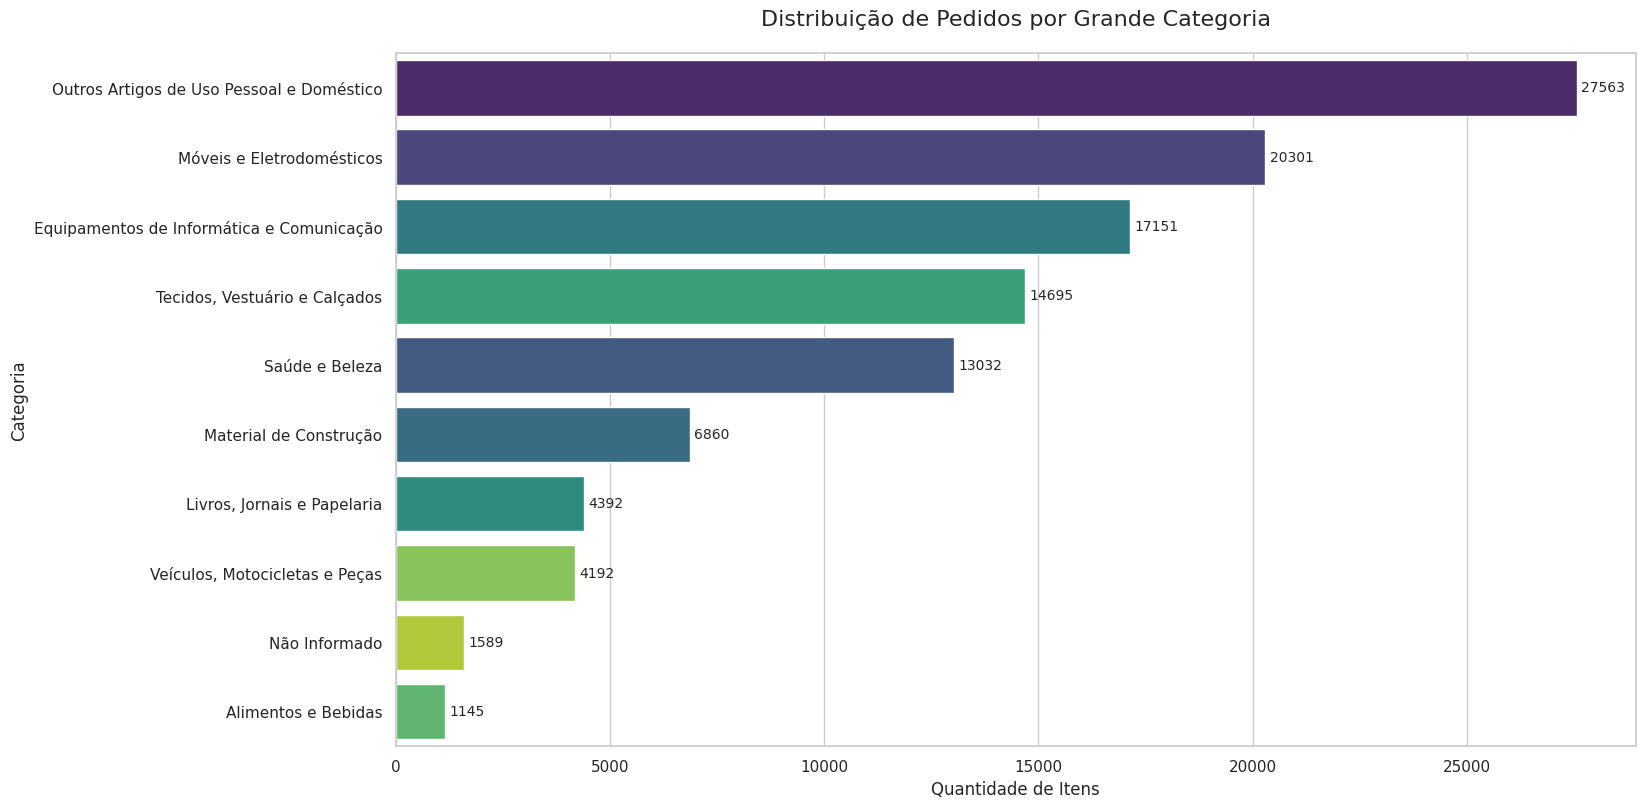

In [64]:
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")
# Definindo a ordem baseada na contagem atualizada
order_list = df_consolidado['product_category_name'].value_counts().index

# Gerando o gráfico com os nomes novos (com espaços e vírgulas)
grafico_vol = sns.countplot(data=df_consolidado, y='product_category_name', order=order_list, palette='viridis', hue='product_category_name', legend=False)

# Adicionando a quantidade na frente de cada barra
for p in grafico_vol.patches:
    width = p.get_width()
    plt.text(width + 100, p.get_y() + p.get_height()/2, f'{int(width)}', va='center', fontsize=10)

plt.title('Distribuição de Pedidos por Grande Categoria', fontsize=16, pad=20)
plt.xlabel('Quantidade de Itens')
plt.ylabel('Categoria')
plt.show()

In [27]:
# Verificando o número de cada categoria e total
counts = df_consolidado['product_category_name'].value_counts()
total_itens = counts.sum()

print("Contagem por Categoria:")
print(counts)
print("\n" + "="*30)
print(f"Quantidade total de itens: {total_itens}")

Contagem por Categoria:
product_category_name
Outros Artigos de Uso Pessoal e Doméstico    27786
Móveis e Eletrodomésticos                    20474
Equipamentos de Informática e Comunicação    17271
Tecidos, Vestuário e Calçados                14849
Saúde e Beleza                               13128
Material de Construção                        6918
Livros, Jornais e Papelaria                   4426
Veículos, Motocicletas e Peças                4235
Não Informado                                 1603
Alimentos e Bebidas                           1167
Name: count, dtype: int64

Quantidade total de itens: 111857


In [28]:
# Verificando por quantos por cento cada categoria é responsável
df_consolidado['product_category_name'].value_counts(normalize=True) * 100

,proportion
product_category_name,
Outros Artigos de Uso Pessoal e Doméstico,24.840645
Móveis e Eletrodomésticos,18.303727
Equipamentos de Informática e Comunicação,15.440250
"Tecidos, Vestuário e Calçados",13.274985
Saúde e Beleza,11.736413
Material de Construção,6.184682
"Livros, Jornais e Papelaria",3.956838
"Veículos, Motocicletas e Peças",3.786084
Não Informado,1.433080


## Categorias e volume de vendas
Verificando o gráfico e os números de cada categoria, é possível verificar que que três categorias são responsáveis por mais de 50% do volume de vendas:
- Outros Artigos de Uso Pessoal e Doméstico
- Móveis e Eletrodomésticos
- Equipamentos de Informática e Comunicação

É necessário verificar também se esses itens também são responsáveis pela maior parte do faturamento.

Irei converter os dados de compra e tempo de entrega no tipo correto também para posterior verificação da timeline de volume e/ou faturamento de vendas.

In [29]:
# Convertendo para datetime
df_consolidado['order_purchase_timestamp'] = pd.to_datetime(df_consolidado['order_purchase_timestamp'])

# Criando colunas de Ano e Mês para facilitar o agrupamento
df_consolidado['ano_mes'] = df_consolidado['order_purchase_timestamp'].dt.to_period('M')

In [30]:
# Calculando a agregação de categorias
analise_categorias = df_consolidado.groupby('product_category_name').agg({
    'price': 'sum',                # GMV
    'order_id': 'nunique',         # Pedidos Únicos
    'order_item_id': 'count'       # Volume de itens
}).reset_index()

analise_categorias['ticket_medio'] = analise_categorias['price'] / analise_categorias['order_id']
analise_categorias = analise_categorias.sort_values(by='price', ascending=False)
analise_categorias

,product_category_name,price,order_id,order_item_id,ticket_medio
6,Outros Artigos de Uso Pessoal e Doméstico,3952768.44,25591,27786,154.459319
4,Móveis e Eletrodomésticos,2327577.99,16762,20474,138.860398
1,Equipamentos de Informática e Comunicação,1902576.26,15383,17271,123.680443
7,Saúde e Beleza,1659373.80,12013,13128,138.131508
8,"Tecidos, Vestuário e Calçados",1379637.34,12857,14849,107.306319
3,Material de Construção,857775.76,5579,6918,153.750808
9,"Veículos, Motocicletas e Peças",592720.11,3897,4235,152.096513
2,"Livros, Jornais e Papelaria",531815.29,4096,4426,129.837717
5,Não Informado,179535.28,1451,1603,123.732102
0,Alimentos e Bebidas,67001.59,974,1167,68.790133


In [31]:
# Criando uma visão formatada do Ticket Médio por Categoria
tabela_ticket_medio = analise_categorias[['product_category_name', 'ticket_medio']].copy()

# Renomeando as colunas para uma melhor visualização
tabela_ticket_medio.columns = ['Categoria', 'Ticket Médio']

# Formatando a coluna de valores para moeda (R$)
tabela_ticket_medio['Ticket Médio'] = tabela_ticket_medio['Ticket Médio'].map('R$ {:,.2f}'.format).str.replace('.', 'v').str.replace(',', '.').str.replace('v', ',')

tabela_ticket_medio.reset_index(drop=True)

,Categoria,Ticket Médio
0,Outros Artigos de Uso Pessoal e Doméstico,"R$ 154,46"
1,Móveis e Eletrodomésticos,"R$ 138,86"
2,Equipamentos de Informática e Comunicação,"R$ 123,68"
3,Saúde e Beleza,"R$ 138,13"
4,"Tecidos, Vestuário e Calçados","R$ 107,31"
5,Material de Construção,"R$ 153,75"
6,"Veículos, Motocicletas e Peças","R$ 152,10"
7,"Livros, Jornais e Papelaria","R$ 129,84"
8,Não Informado,"R$ 123,73"
9,Alimentos e Bebidas,"R$ 68,79"


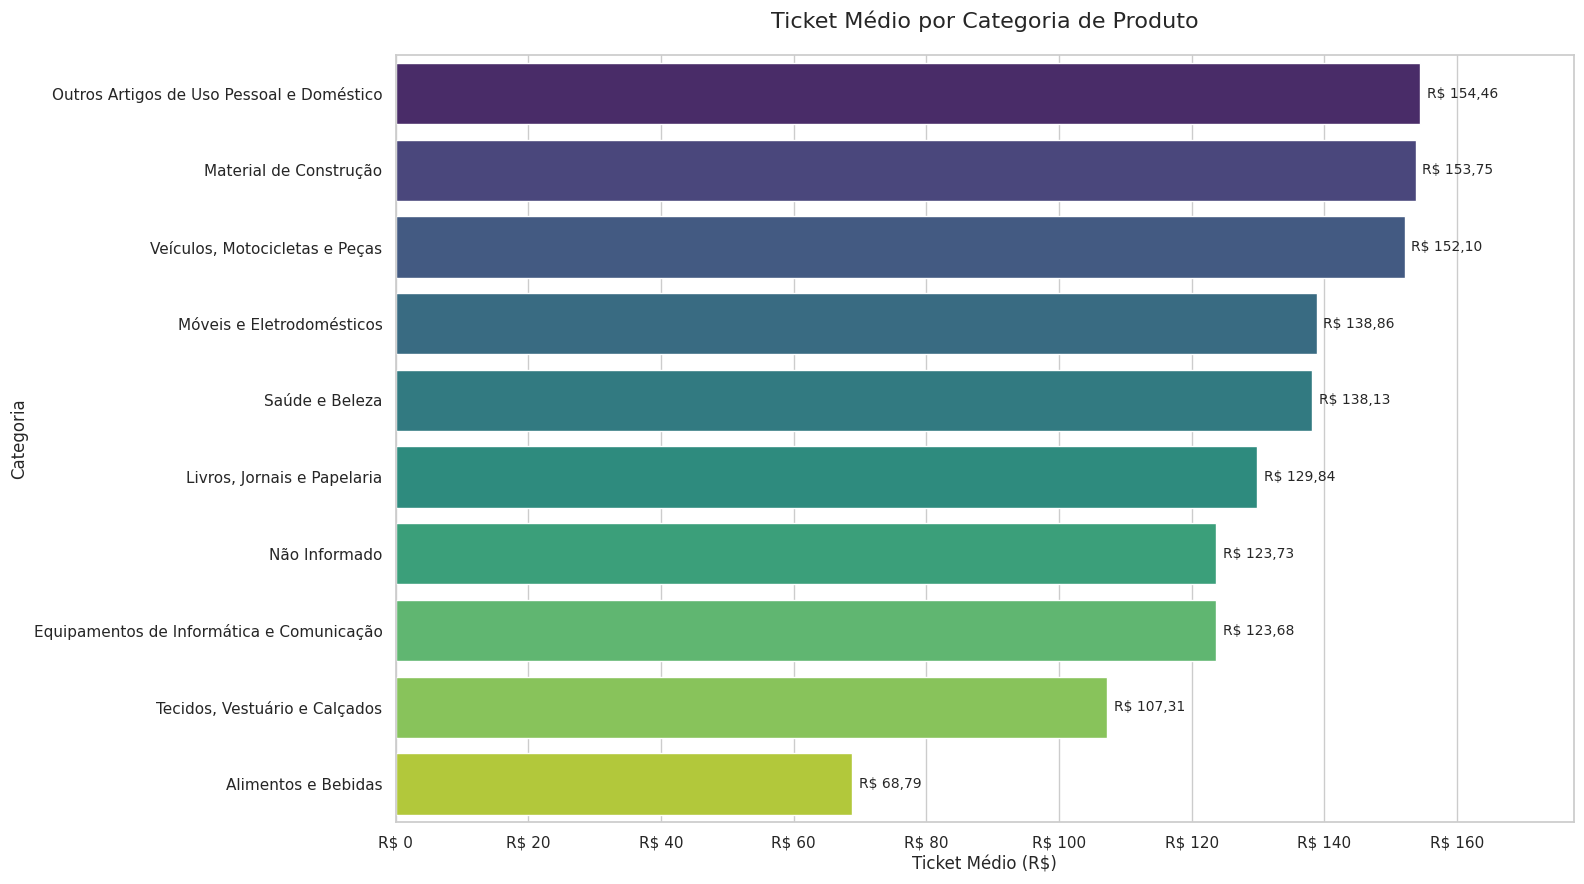

In [32]:
from matplotlib.ticker import FuncFormatter

# Preparando os dados e ordenando pelo ticket médio
dados_grafico = analise_categorias.sort_values(by='ticket_medio', ascending=False)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras horizontal
grafico_ticket = sns.barplot(
    data=dados_grafico,
    x='ticket_medio',
    y='product_category_name',
    palette='viridis',
    hue='product_category_name',
    legend=False
)

# Adicionando os valores nas barras para facilitar a leitura
for i, valor in enumerate(dados_grafico['ticket_medio']):
    plt.text(valor + 1, i, f'R$ {valor:.2f}'.replace('.', ','), va='center', fontsize=10)

plt.title('Ticket Médio por Categoria de Produto', fontsize=16, pad=20)
plt.xlabel('Ticket Médio (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Ajustando o limite do eixo X para dar espaço ao texto das etiquetas
plt.xlim(0, dados_grafico['ticket_medio'].max() * 1.15)

# Formatação monetária no eixo X
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x:,.0f}'.replace(',', '.')))

plt.tight_layout()
plt.show()

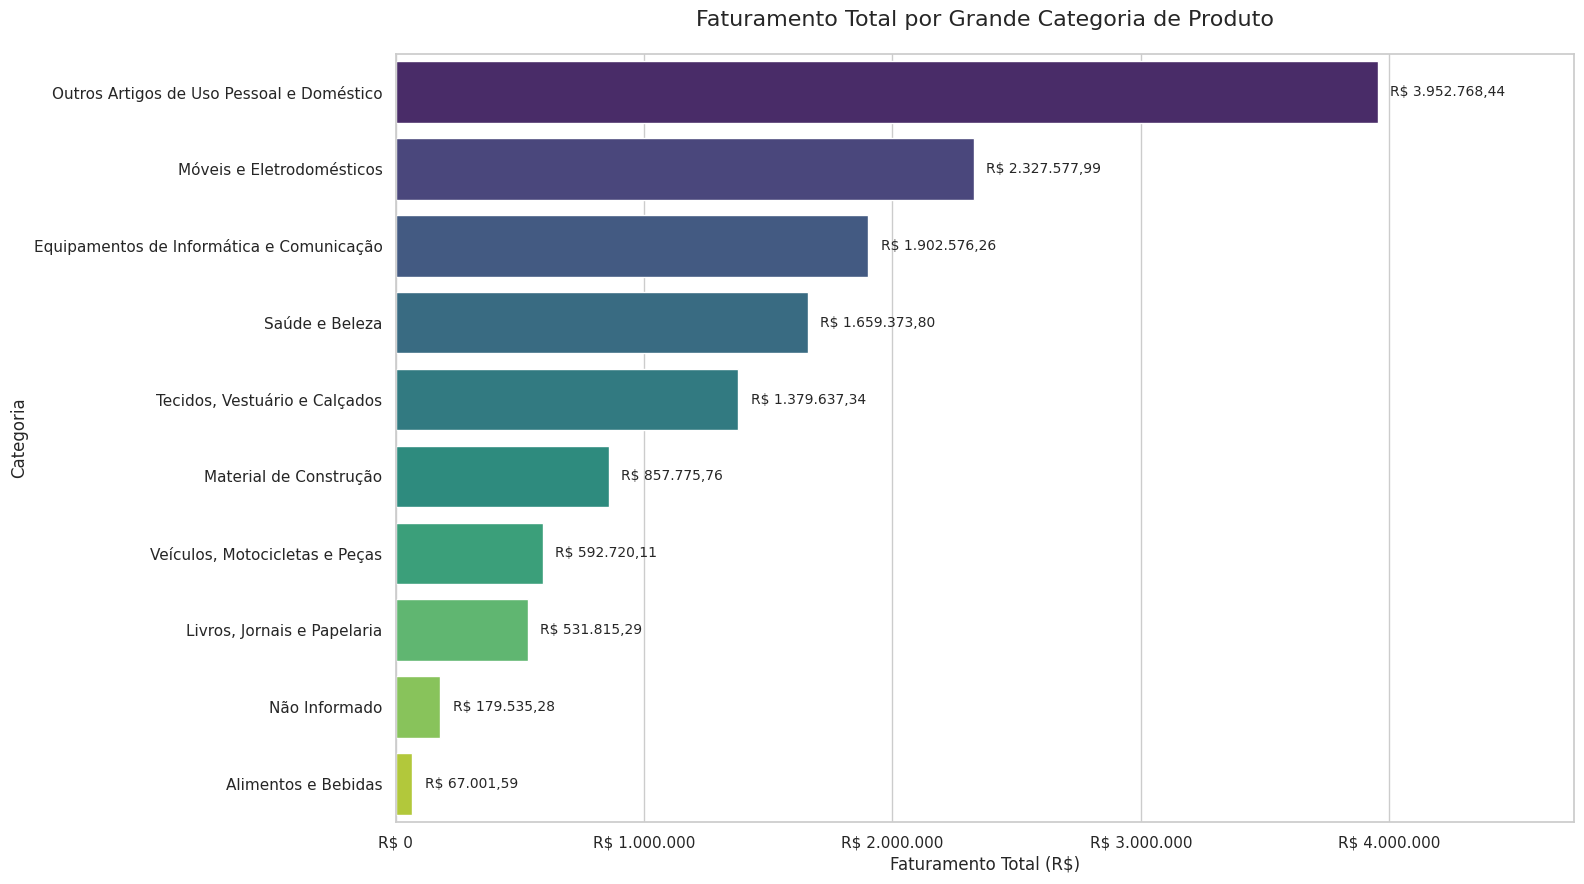

In [33]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 9))

grafico_faturamento = sns.barplot(
    data=analise_categorias,
    x='price',
    y='product_category_name',
    hue='product_category_name',
    palette='viridis',
    legend=False
)

# Adicionando os valores formatados na frente de cada barra
for p in grafico_faturamento.patches:
    width = p.get_width()
    plt.text(width + 50000, p.get_y() + p.get_height()/2,
             f'R$ {width:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'),
             va='center', fontsize=10)

plt.title('Faturamento Total por Grande Categoria de Produto', fontsize=16, pad=20)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Ajustando o limite do eixo X para acomodar as etiquetas
plt.xlim(0, analise_categorias['price'].max() * 1.2)

from matplotlib.ticker import FuncFormatter
grafico_faturamento.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x:,.0f}'.replace(',', '.')))

plt.tight_layout()
plt.show()

In [34]:
# Criando uma visão formatada do Faturamento Total (GMV) por Categoria
tabela_faturamento = analise_categorias[['product_category_name', 'price']].copy()

# Renomeando as colunas para uma melhor visualização
tabela_faturamento.columns = ['Categoria', 'Faturamento Total (GMV)']

# Formatando a coluna de valores para moeda (R$)
tabela_faturamento['Faturamento Total (GMV)'] = tabela_faturamento['Faturamento Total (GMV)'].map('R$ {:,.2f}'.format).str.replace('.', 'v').str.replace(',', '.').str.replace('v', ',')

# Exibindo a tabela
tabela_faturamento.reset_index(drop=True)

,Categoria,Faturamento Total (GMV)
0,Outros Artigos de Uso Pessoal e Doméstico,"R$ 3.952.768,44"
1,Móveis e Eletrodomésticos,"R$ 2.327.577,99"
2,Equipamentos de Informática e Comunicação,"R$ 1.902.576,26"
3,Saúde e Beleza,"R$ 1.659.373,80"
4,"Tecidos, Vestuário e Calçados","R$ 1.379.637,34"
5,Material de Construção,"R$ 857.775,76"
6,"Veículos, Motocicletas e Peças","R$ 592.720,11"
7,"Livros, Jornais e Papelaria","R$ 531.815,29"
8,Não Informado,"R$ 179.535,28"
9,Alimentos e Bebidas,"R$ 67.001,59"


## Categorias e faturamento
Através do gráfico, é possível verificar que há uma relação entre os três primeiras categorias com maior quantidade de vendas e maior quantidade de faturamento.
- Outros Artigos de Uso Pessoal e Doméstico
- Móveis e Eletrodomésticos
- Equipamentos de Informática e Comunicação

In [35]:
# Criar o filtro para o ano de 2017
# Selecionamos apenas as linhas entre 01/01/2017 e 31/12/2017
mask_2017 = (df_consolidado['order_purchase_timestamp'] >= '2017-01-01') & \
            (df_consolidado['order_purchase_timestamp'] <= '2017-12-31')

df_2017 = df_consolidado.loc[mask_2017].copy()

# Criar a coluna Mensal e Agrupar
df_2017['mes_ano'] = df_2017['order_purchase_timestamp'].dt.to_period('M').astype(str)
evolucao_2017 = df_2017.groupby('mes_ano')['price'].sum().reset_index()

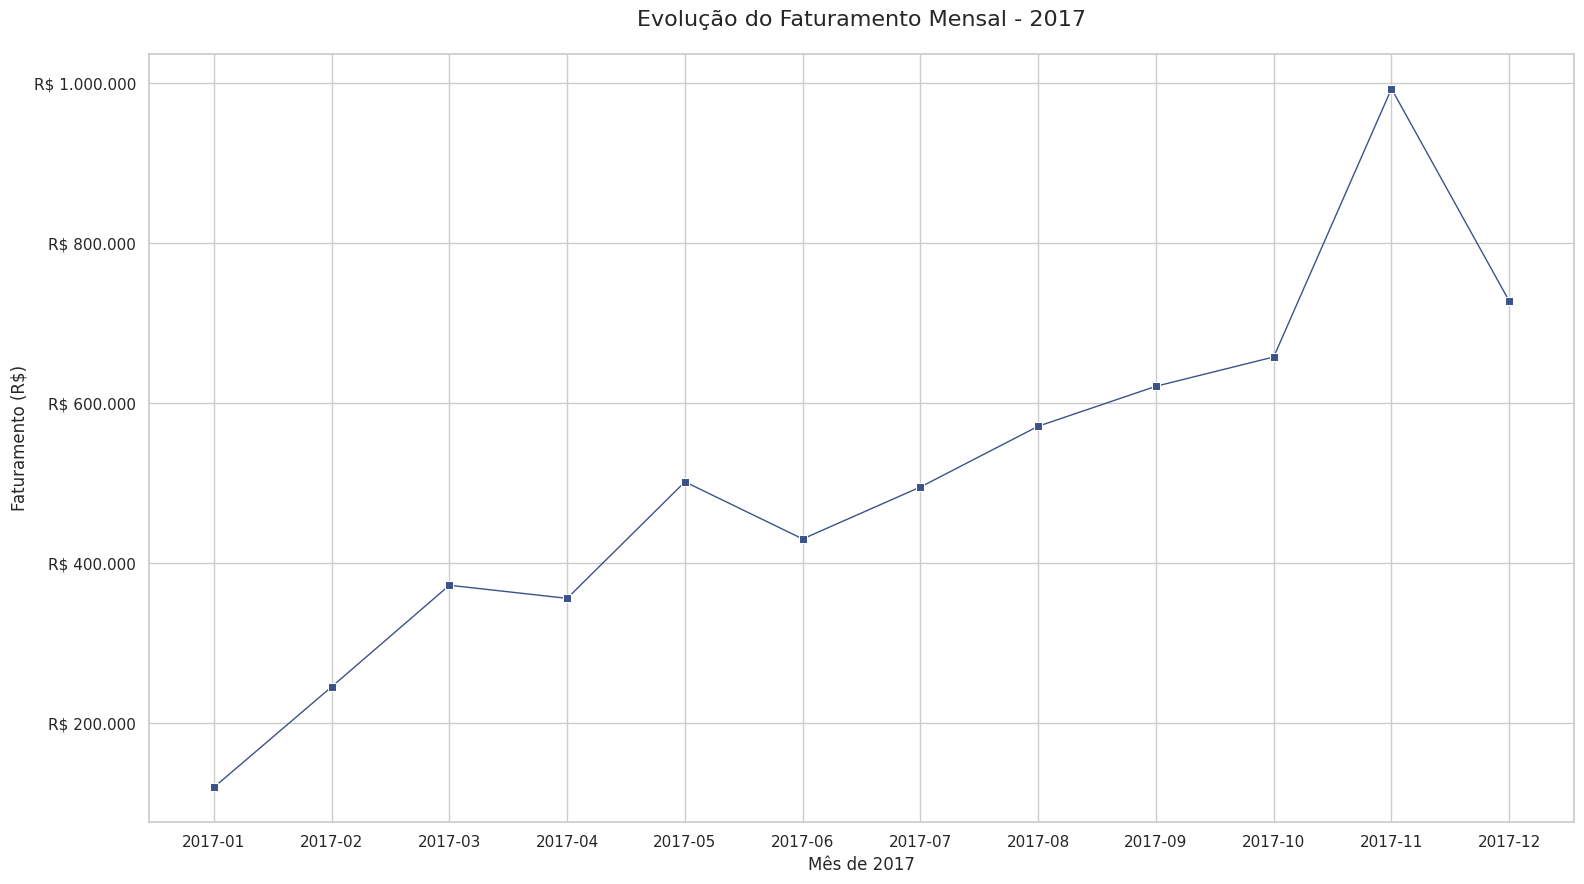

In [65]:
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Obtendo uma cor específica da paleta viridis (azul escuro/médio)
# A paleta viridis vai do roxo/azul ao amarelo; o índice 0.2 costuma ser um azul bem característico
cor_viridis_azul = plt.cm.viridis(0.25)

# Plotagem com a nova cor
sns.lineplot(data=evolucao_2017, x='mes_ano', y='price', marker='s', color=cor_viridis_azul, linewidth=1)

# Customização
plt.title('Evolução do Faturamento Mensal - 2017', fontsize=16, pad=20)
plt.xlabel('Mês de 2017', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

# Formatação monetária no eixo Y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x:,.0f}'.replace(',', '.')))

plt.tight_layout()
plt.show()

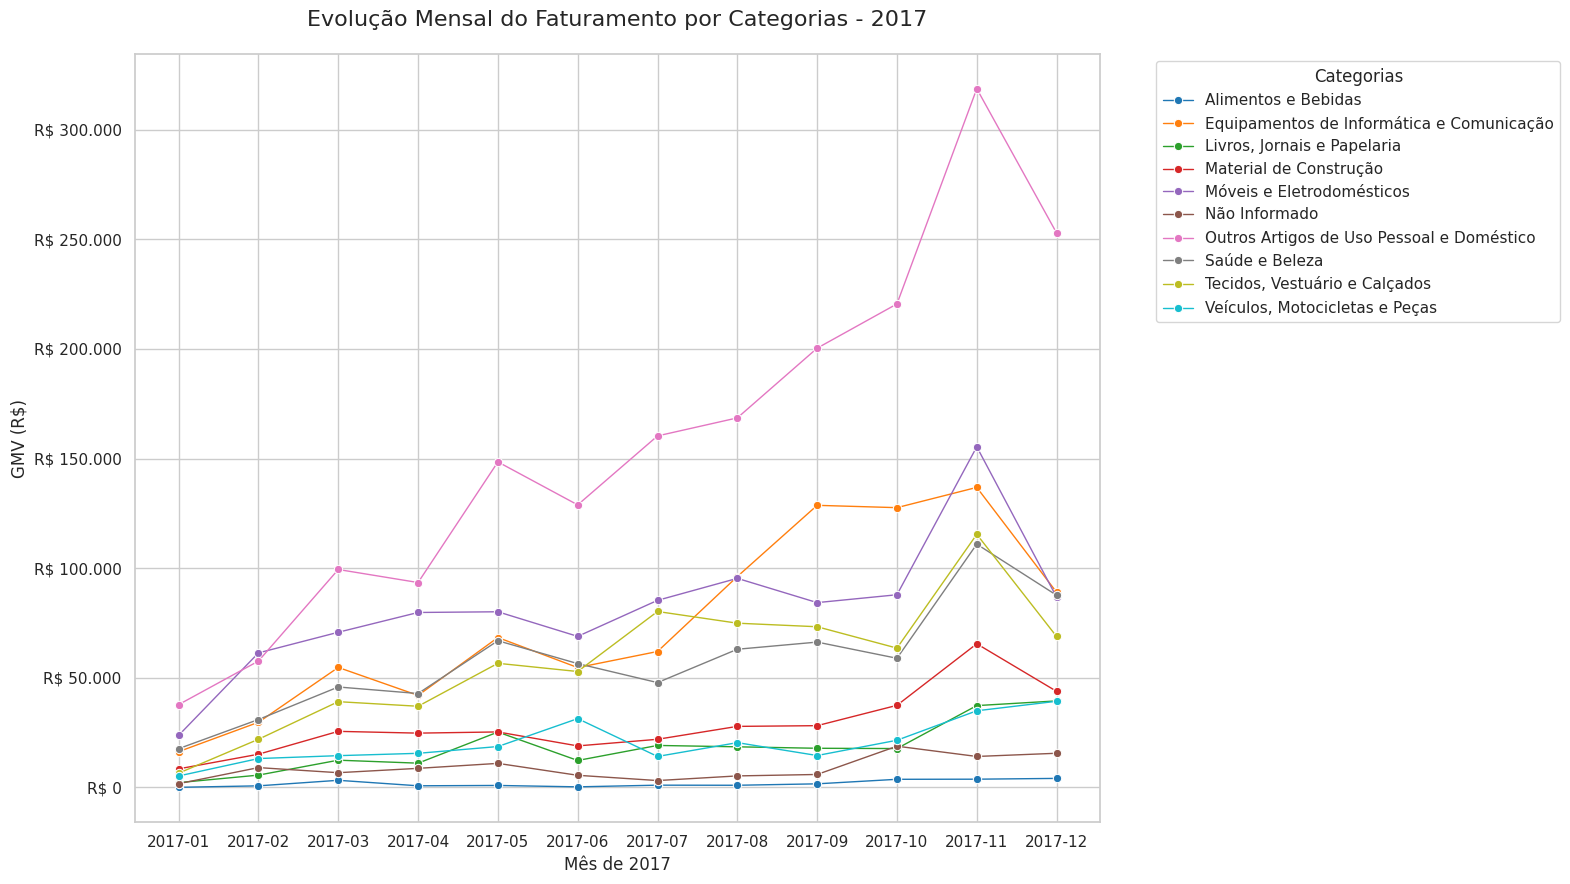

In [37]:
df_gmv_mensal = df_2017.groupby(['mes_ano', 'product_category_name'])['price'].sum().reset_index()

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Usando a paleta 'tab10' para maior contraste entre as categorias
sns.lineplot(
    data=df_gmv_mensal,
    x='mes_ano',
    y='price',
    hue='product_category_name',
    marker='o',
    palette='tab10',
    linewidth=1
)

plt.title('Evolução Mensal do Faturamento por Categorias - 2017', fontsize=16, pad=20)
plt.ylabel('GMV (R$)', fontsize=12)
plt.xlabel('Mês de 2017', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Categorias')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x:,.0f}'.replace(',', '.')))

plt.tight_layout()
plt.show()

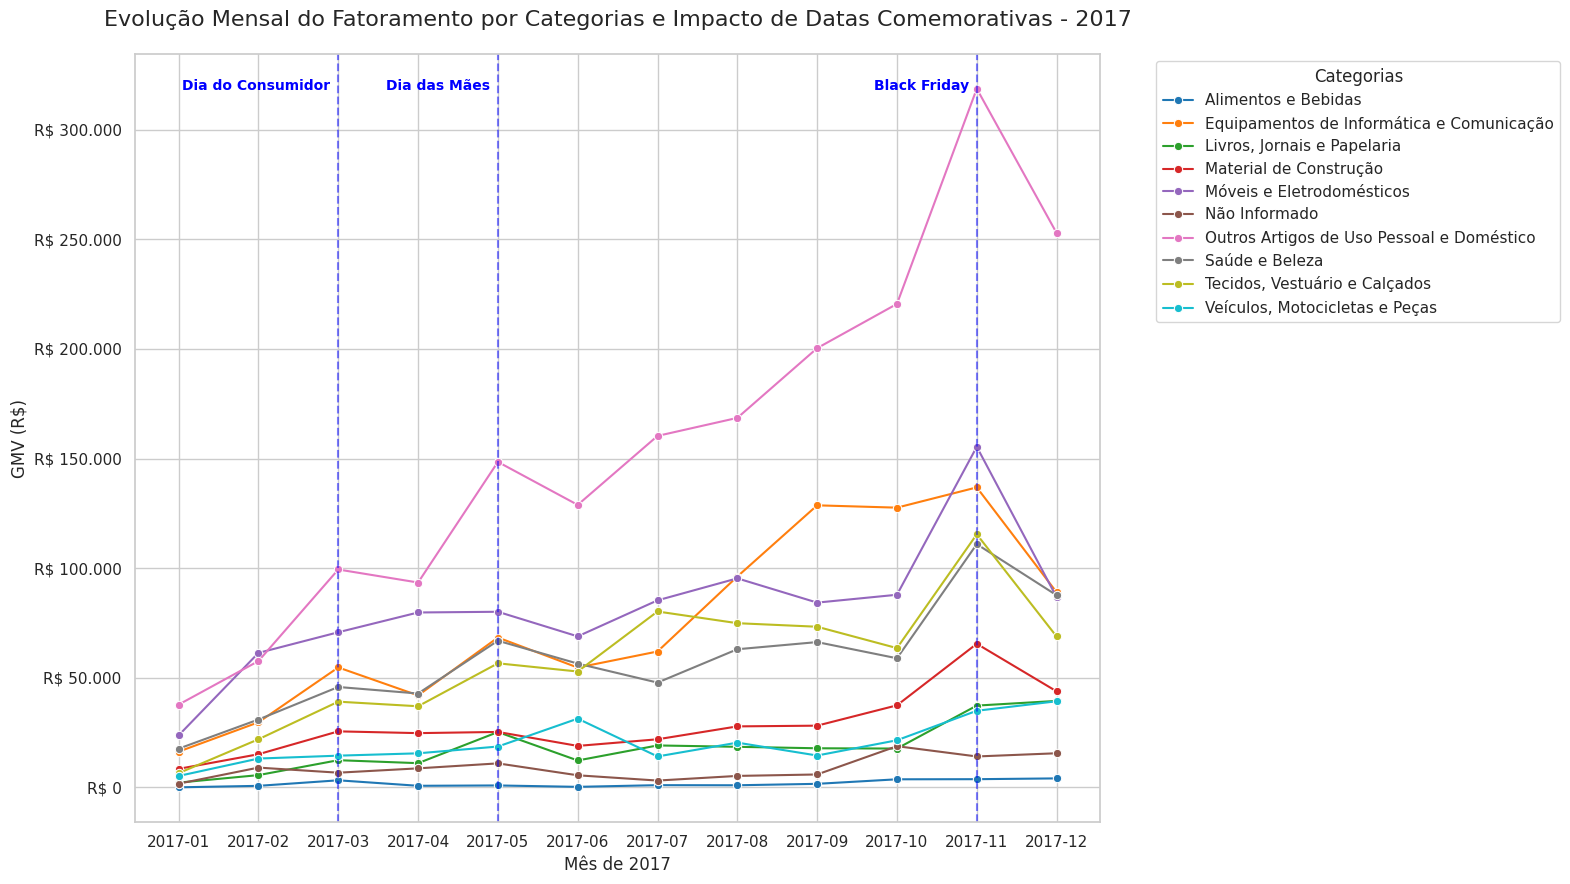

In [38]:
df_gmv_mensal = df_2017.groupby(['mes_ano', 'product_category_name'])['price'].sum().reset_index()

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Criando o gráfico de evolução por categoria
sns.lineplot(
    data=df_gmv_mensal,
    x='mes_ano',
    y='price',
    hue='product_category_name',
    marker='o',
    palette='tab10',
    linewidth=1.5
)

# Definindo as datas comemorativas
datas_comemorativas = [
    ('2017-03', 'Dia do Consumidor'),
    ('2017-05', 'Dia das Mães'),
    ('2017-11', 'Black Friday')
]

# Adicionando as linhas verticais e etiquetas com ajuste para a esquerda
for i, (mes, label) in enumerate(datas_comemorativas):
    plt.axvline(x=mes, color='blue', linestyle='--', alpha=0.5)

    # Convertendo a posição x para um índice numérico para subtrair o offset e mover à esquerda
    x_pos = list(evolucao_2017['mes_ano']).index(mes)

    # Usamos x_pos - 0.1 para deslocar o texto para a esquerda da linha
    plt.text(x_pos - 0.1, plt.ylim()[1] * 0.95, label, color='blue',
             fontweight='bold', ha='right', fontsize=10, rotation=0)

# Customização Final
plt.title('Evolução Mensal do Fatoramento por Categorias e Impacto de Datas Comemorativas - 2017', fontsize=16, pad=20)
plt.ylabel('GMV (R$)', fontsize=12)
plt.xlabel('Mês de 2017', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Categorias')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x:,.0f}'.replace(',', '.')))

plt.tight_layout()
plt.show()

In [39]:
# Definindo as colunas logísticas que precisamos de df_orders
colunas_logistica = [
    'order_id',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Adicionando essas colunas ao df_consolidado
# Verificar quais colunas logísticas ainda não existem no df_consolidado
colunas_faltantes = [c for c in colunas_logistica if c not in df_consolidado.columns or c == 'order_id']

if len(colunas_faltantes) > 1:
    df_consolidado = pd.merge(df_consolidado, df_orders[colunas_faltantes], on='order_id', how='left')

# Preparar as Reviews tirando a média por pedido (para resolver os 551 casos duplicados)
df_reviews_unique = df_reviews.groupby('order_id')['review_score'].mean().reset_index()

# Adicionar a Satisfação ao df_consolidado
if 'review_score' not in df_consolidado.columns:
    df_consolidado = pd.merge(df_consolidado, df_reviews_unique, on='order_id', how='left')

# Convertendo todas as datas para datetime para permitir cálculos
colunas_datas = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in colunas_datas:
    if col in df_consolidado.columns:
        df_consolidado[col] = pd.to_datetime(df_consolidado[col])

print("Colunas atuais no DataFrame:", df_consolidado.columns.tolist())

Colunas atuais no DataFrame: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'order_purchase_timestamp', 'ano_mes', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score']


## Status dos Pedidos
Após consolidar os dados em categorias e verificar o faturamento e o volume de vendas, fiquei curioso para saber o status de cada pedido e se o dataset inclui apenas pedidos avaliados.

Vamos validar se a análise atual inclui pedidos cancelados ou não entregues, cruzando os dados consolidados com o status oficial da tabela de pedidos.

In [40]:
# Filtrando o dataset para manter apenas registros que possuem avaliação
# Isso garante que a análise de satisfação seja baseada em feedbacks reais

print(f"Linhas antes da filtragem: {len(df_consolidado)}")

# Removendo linhas onde o review_score é nulo
df_consolidado = df_consolidado.dropna(subset=['review_score']).copy()

print(f"Linhas após a filtragem (apenas com review): {len(df_consolidado)}")

# Verificando a distribuição de status para os pedidos que restaram com avaliação
print("\nDistribuição de Status para pedidos avaliados:")
print(pd.merge(df_consolidado[['order_id']], df_orders[['order_id', 'order_status']], on='order_id')['order_status'].value_counts())

Linhas antes da filtragem: 111857
Linhas após a filtragem (apenas com review): 110920

Distribuição de Status para pedidos avaliados:
order_status
delivered      108597
shipped          1090
canceled          524
processing        350
invoiced          349
unavailable         7
approved            3
Name: count, dtype: int64


Como podemos ver, a esmagadora maioria dos pedidos avaliados foi entregue, porém há pedidos avaliados que possuem status diversos. Tais dados merecem investigação também.

In [41]:
# Tempo real de entrega em dias
df_consolidado['tempo_entrega'] = (df_consolidado['order_delivered_customer_date'] - df_consolidado['order_purchase_timestamp']).dt.days

# Dias de atraso (valor positivo indica entrega após o prazo)
df_consolidado['atraso_dias'] = (df_consolidado['order_delivered_customer_date'] - df_consolidado['order_estimated_delivery_date']).dt.days

# Criando uma coluna para identificar se houve atraso (True/False)
df_consolidado['houve_atraso'] = df_consolidado['atraso_dias'] > 0

## Correlação entre métricas operacionais e a satisfação

In [42]:
# Criando indicador para pedidos não entregues (status diferente de 'delivered')
df_consolidado['nao_entregue'] = (df_consolidado['order_id'].map(df_orders.set_index('order_id')['order_status']) != 'delivered').astype(int)

# Correlação de Pearson incluindo o status de não entrega
correlacao = df_consolidado[['review_score', 'freight_value', 'tempo_entrega', 'atraso_dias', 'nao_entregue']].corr()
print("Matriz de Correlação com a Satisfação:")
print(correlacao['review_score'])

# Ranking de Atrasos por Categoria
ranking_atraso = df_consolidado.groupby('product_category_name')['houve_atraso'].mean().sort_values(ascending=False)
print("\nTaxa de Atraso por Categoria:")
print(ranking_atraso)

Matriz de Correlação com a Satisfação:
review_score     1.000000
freight_value   -0.036375
tempo_entrega   -0.305552
atraso_dias     -0.229422
nao_entregue    -0.241051
Name: review_score, dtype: float64

Taxa de Atraso por Categoria:
product_category_name
Não Informado                                0.071743
Saúde e Beleza                               0.069828
Veículos, Motocicletas e Peças               0.068225
Livros, Jornais e Papelaria                  0.065346
Equipamentos de Informática e Comunicação    0.065244
Tecidos, Vestuário e Calçados                0.063015
Outros Artigos de Uso Pessoal e Doméstico    0.062294
Material de Construção                       0.060787
Móveis e Eletrodomésticos                    0.059800
Alimentos e Bebidas                          0.053275
Name: houve_atraso, dtype: float64


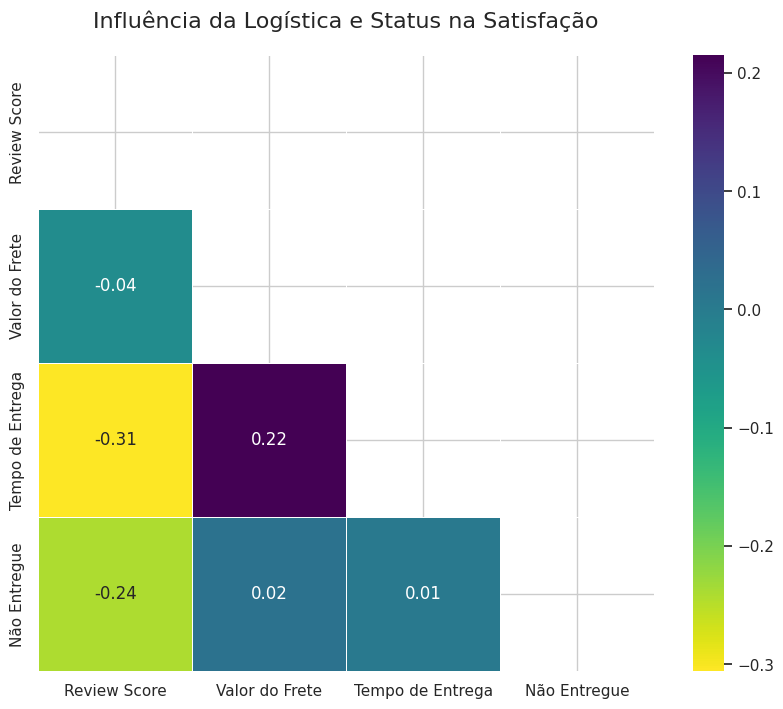

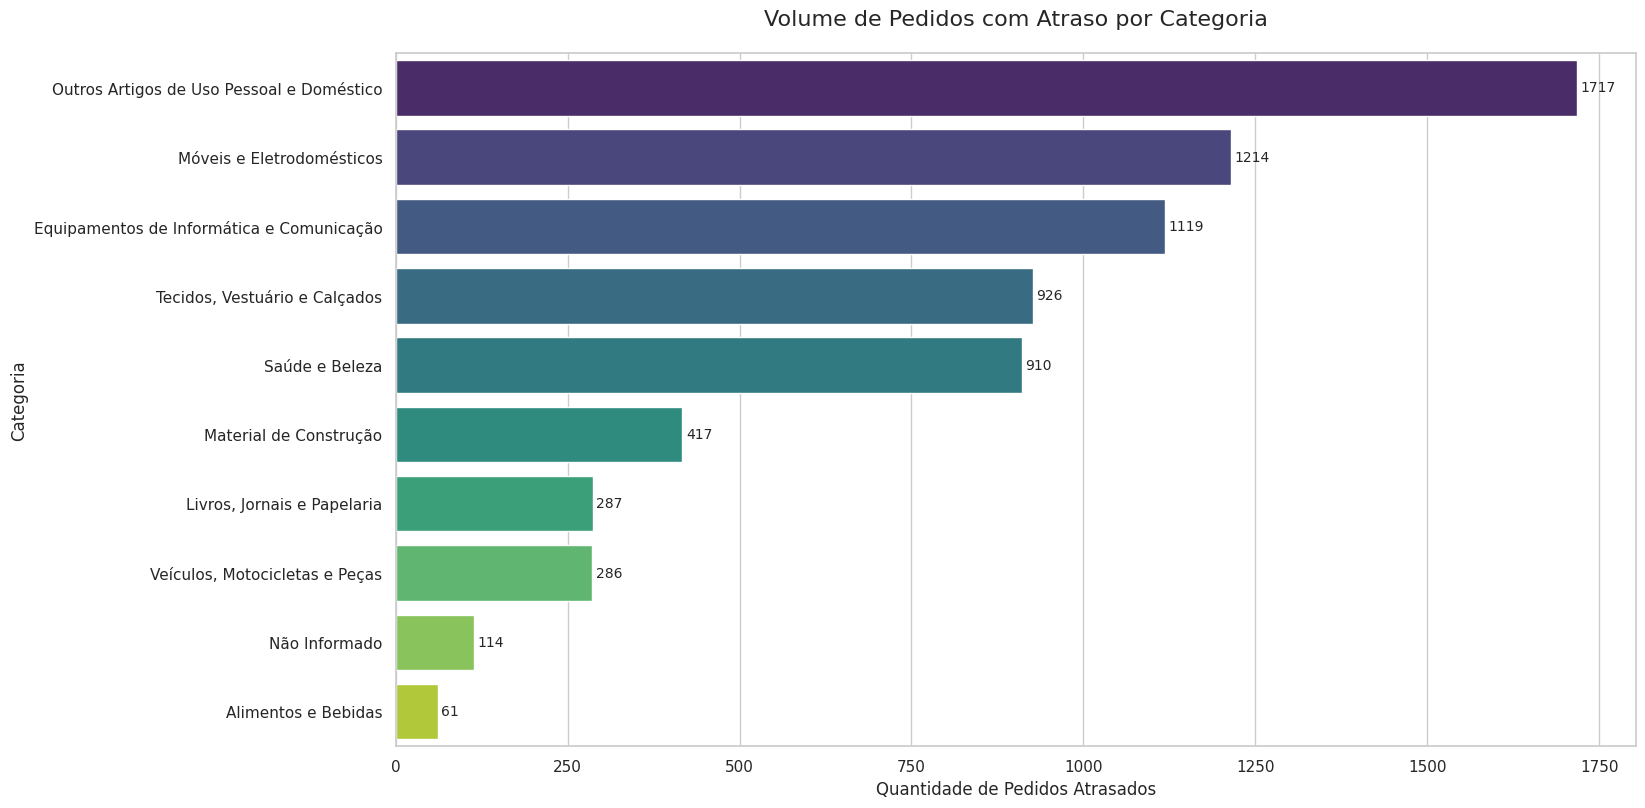

Taxa de Atraso por Categoria (%):


,Categoria,Taxa de Atraso
0,Outros Artigos de Uso Pessoal e Doméstico,6.23%
1,Móveis e Eletrodomésticos,5.98%
2,Equipamentos de Informática e Comunicação,6.52%
3,"Tecidos, Vestuário e Calçados",6.30%
4,Saúde e Beleza,6.98%
5,Material de Construção,6.08%
6,"Livros, Jornais e Papelaria",6.53%
7,"Veículos, Motocicletas e Peças",6.82%
8,Não Informado,7.17%
9,Alimentos e Bebidas,5.33%


In [43]:
# Criando indicador para pedidos não entregues para análise de correlação
df_consolidado['nao_entregue'] = df_consolidado['order_id'].map(df_orders.set_index('order_id')['order_status'] != 'delivered').astype(int)

# Calculando a correlação
correlacao_log = df_consolidado[['review_score', 'freight_value', 'tempo_entrega', 'nao_entregue']].corr()

# Renomeando as colunas para o gráfico
labels_limpos = {
    'review_score': 'Review Score',
    'freight_value': 'Valor do Frete',
    'tempo_entrega': 'Tempo de Entrega',
    'nao_entregue': 'Não Entregue'
}
correlacao_log.rename(index=labels_limpos, columns=labels_limpos, inplace=True)

# Criando a máscara para o triângulo superior
mask = np.triu(np.ones_like(correlacao_log, dtype=bool))

# Gráfico de Correlação Logística (Triangle Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_log, mask=mask, annot=True, cmap='viridis_r', center=None, fmt=".2f", square=True, linewidths=.5)
plt.title('Influência da Logística e Status na Satisfação', fontsize=16, pad=20)
plt.show()

# --- Nova Análise de Atrasos ---

# Calculando volume absoluto e taxa de atraso
stats_atraso = df_consolidado.groupby('product_category_name').agg({
    'houve_atraso': ['sum', 'mean']
}).reset_index()

stats_atraso.columns = ['Categoria', 'Pedidos Atrasados', 'Taxa de Atraso']
stats_atraso = stats_atraso.sort_values(by='Pedidos Atrasados', ascending=False)

# Gráfico: Volume de Pedidos Atrasados
plt.figure(figsize=(16, 9))
sns.barplot(data=stats_atraso, x='Pedidos Atrasados', y='Categoria', hue='Categoria', palette='viridis', legend=False)

# Adicionando rótulos de dados
for i, valor in enumerate(stats_atraso['Pedidos Atrasados']):
    plt.text(valor + 5, i, f'{int(valor)}', va='center', fontsize=10)

plt.title('Volume de Pedidos com Atraso por Categoria', fontsize=16, pad=20)
plt.xlabel('Quantidade de Pedidos Atrasados')
plt.ylabel('Categoria')
plt.show()

# Exibindo Tabela de Taxa de Atrasos
print("Taxa de Atraso por Categoria (%):")
tabela_taxa = stats_atraso[['Categoria', 'Taxa de Atraso']].copy()
tabela_taxa['Taxa de Atraso'] = (tabela_taxa['Taxa de Atraso'] * 100).map('{:.2f}%'.format)
display(tabela_taxa.reset_index(drop=True))

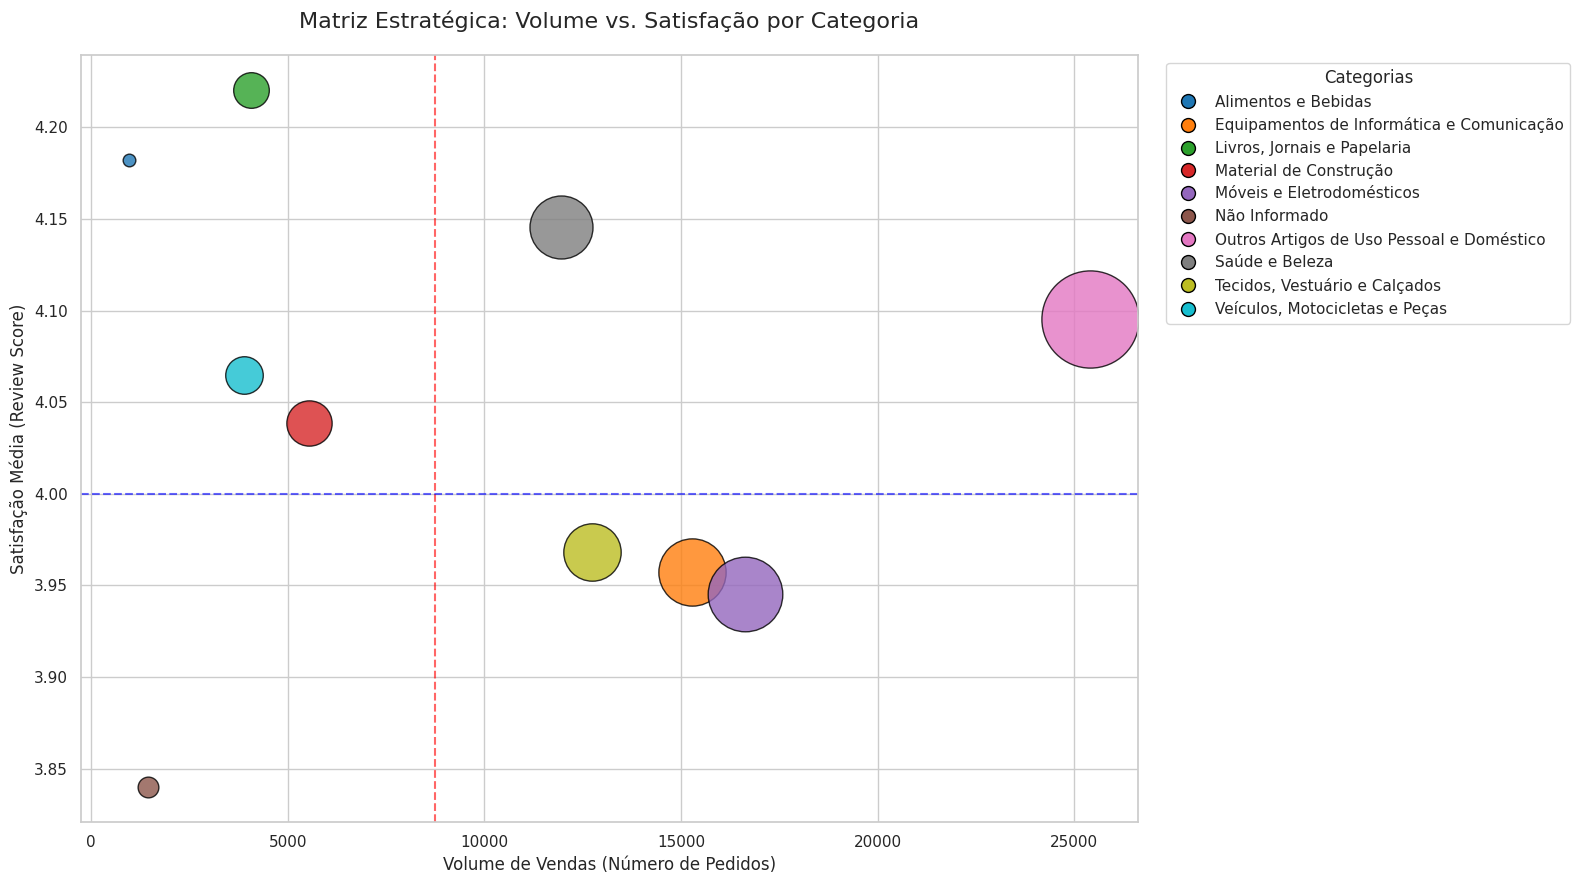

In [44]:
import matplotlib.lines as mlines

# Agrupando os dados por categoria para calcular as métricas da matriz
df_matriz = df_consolidado.groupby('product_category_name').agg({
    'order_id': 'nunique',
    'review_score': 'mean',
    'price': 'sum'
}).reset_index()

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

categorias = sorted(df_matriz['product_category_name'].unique())
cores = sns.color_palette("tab10", len(categorias))
color_map = dict(zip(categorias, cores))

# Plotando cada categoria individualmente como um gráfico de bolhas
for cat in categorias:
    dados_cat = df_matriz[df_matriz['product_category_name'] == cat]
    plt.scatter(
        x=dados_cat['order_id'],
        y=dados_cat['review_score'],
        s=dados_cat['price'] / 800,  # Fator de escala para o tamanho da bolha
        color=color_map[cat],
        alpha=0.8,
        edgecolors="black"
    )

# Adicionando linhas de referência (Corte mediano de volume e nota alvo 4.0)
x_corte = df_matriz['order_id'].median()
y_fixo = 4.0

plt.axvline(x=x_corte, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Mediana de Volume')
plt.axhline(y=y_fixo, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label='Nota Alvo (4.0)')

# Customização de títulos e eixos
plt.title('Matriz Estratégica: Volume vs. Satisfação por Categoria', fontsize=16, pad=20)
plt.xlabel('Volume de Vendas (Número de Pedidos)', fontsize=12)
plt.ylabel('Satisfação Média (Review Score)', fontsize=12)

# Criação manual da legenda para garantir que as cores correspondam às categorias
legend_handles = [
    mlines.Line2D([], [], color='white', marker='o', linestyle='None',
                  markersize=10, markerfacecolor=color_map[cat],
                  markeredgecolor='black', label=cat)
    for cat in categorias
]

plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Categorias')
plt.tight_layout()
plt.show()

A tabela acima é uma matriz semelhante à Matriz BCG. Ela mostra a relação entre o volume de vendas e a satisfação do cliente para cada categoria, ao mesmo tempo que mostra o faturamento (GMV) de cada categoria através do tamanho da bolha.

1. Quadrante superior esquerdo:
    - São categorias que possuem boas notas (acima de 4), porém tem baixo volume de vendas. São categorias que merecem maior divulgação e investimento.
2. Quadrante superior direito:
    - São categorias que possuem alto volume de vendas. São categorias que devem ser mantidas ou expandidas.
3. Quadrante inferior esquerdo:
    - Apenas uma categoria caiu nesse quadrante, que são os pedidos que não foram categorizados. Possui baixo volume de vendas e nota baixa também.
4. Quadrante inferior direito:
    - São categorias com alto volume de vendas, mas que possuem avaliação abaixo do ideal. Essas categorias são as que possuem maior influência na satisfação geral do cliente e devem ser priorizadas.

O gráfico utiliza itens com todos os status, mas que possuem algume avaliação. Irei verificar em um novo gráfico apenas aqueles que possuem o status entregue para fins de comparação e análise.

## Matriz Estratégica de Pedidos Apenas Entregues
Título autoexplicativo.

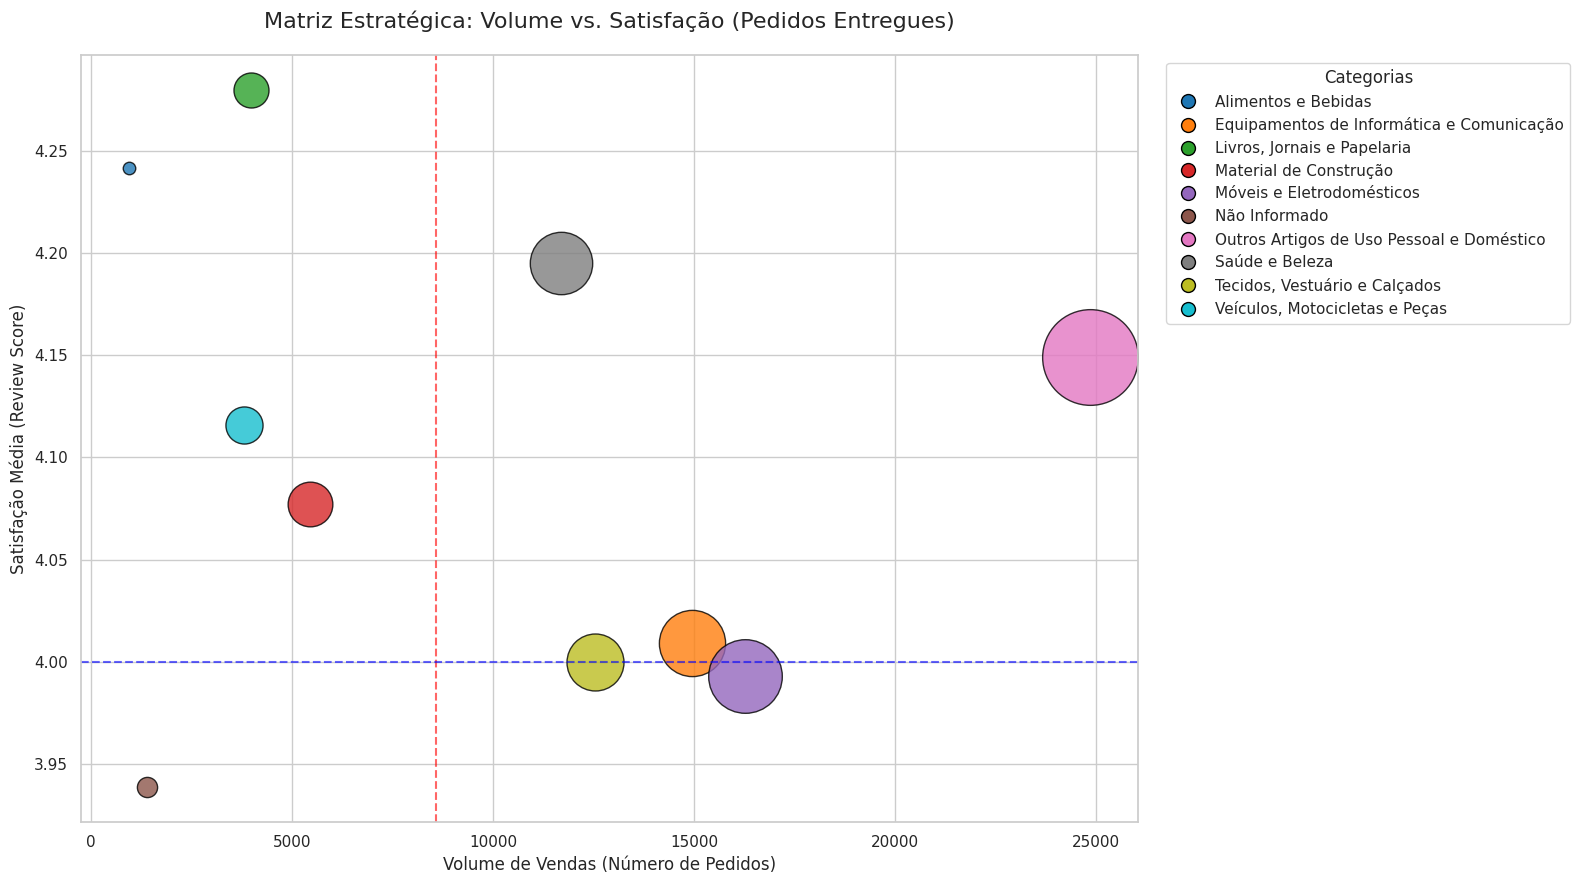

In [45]:
import matplotlib.lines as mlines

# Filtrando apenas pedidos entregues e que possuem status oficial
df_entregues_status = pd.merge(df_consolidado, df_orders[['order_id', 'order_status']], on='order_id', how='left')
df_matriz_entregues = df_entregues_status[df_entregues_status['order_status'] == 'delivered'].copy()

# Agrupando por categoria
matriz_data = df_matriz_entregues.groupby('product_category_name').agg({
    'order_id': 'nunique',    # Volume
    'review_score': 'mean',   # Satisfação
    'price': 'sum'            # Faturamento (tamanho)
}).reset_index()

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Mapeamento de cores consistente
categorias = sorted(matriz_data['product_category_name'].unique())
cores = sns.color_palette("tab10", len(categorias))
color_map = dict(zip(categorias, cores))

# Plotando o gráfico de bolhas
for cat in categorias:
    dados_cat = matriz_data[matriz_data['product_category_name'] == cat]
    plt.scatter(
        x=dados_cat['order_id'],
        y=dados_cat['review_score'],
        s=dados_cat['price'] / 800, # Escala similar ao anterior
        color=color_map[cat],
        alpha=0.8,
        edgecolors="black"
    )

# Referências
x_corte = matriz_data['order_id'].median()
y_fixo = 4.0

plt.axvline(x=x_corte, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Mediana de Volume')
plt.axhline(y=y_fixo, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label='Nota Alvo (4.0)')

plt.title('Matriz Estratégica: Volume vs. Satisfação (Pedidos Entregues)', fontsize=16, pad=20)
plt.xlabel('Volume de Vendas (Número de Pedidos)', fontsize=12)
plt.ylabel('Satisfação Média (Review Score)', fontsize=12)

# Legenda
legend_handles = [
    mlines.Line2D([], [], color='white', marker='o', linestyle='None',
                  markersize=10, markerfacecolor=color_map[cat],
                  markeredgecolor='black', label=cat)
    for cat in categorias
]

plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Categorias')
plt.tight_layout()
plt.show()

Podemos ver, comparando as duas matrizes, que os pedidos com status não entregues influenciam bastante na satisfação de três categorias:
- Tecidos, Vestuários e Calçados
- Móveis e Eletrodomésticos
- Equipamentos de Informática e Comunicação

Apesar de as categorias subirem e ficarem bem próximas de entrar no quadrante de itens de alta performance, eles estão no limiar do aceitável.

Eles serem afetados também demonstram que são categorias que possuem problemas logísticos e merecem uma atenção especial.

In [46]:
# Garantir que só teremos pedidos que possuem uma nota (review_score)
df_avaliados = pd.merge(df_orders[['order_id', 'order_status']],
                        df_reviews[['order_id', 'review_score', 'review_comment_message']],
                        on='order_id', how='inner')

# Proporção de Status
print("--- Proporção de Status (Apenas Pedidos que Receberam Nota) ---")
# O value_counts aqui já está restrito ao dataframe de inner join
proporcao_avaliados = df_avaliados['order_status'].value_counts(normalize=True) * 100

# Formatando para exibição limpa
for status, perc in proporcao_avaliados.items():
    print(f"{status}: {perc:.2f}%")

print("\n" + "="*60 + "\n")

# Amostra de Comentários
print("--- Evidências Qualitativas: Nota 1 em Pedidos Sem Status 'delivered' ---")

# Filtro: Não entregues, Nota 1 e Comentário presente
filtro_frustracao = (df_avaliados['order_status'] != 'delivered') & \
                    (df_avaliados['review_score'] == 1) & \
                    (df_avaliados['review_comment_message'].notnull())

# Selecionando 3 comentários aleatórios para ilustrar o ponto
if df_avaliados[filtro_frustracao].shape[0] > 0:
    amostra = df_avaliados[filtro_frustracao]['review_comment_message'].sample(3, random_state=42)

    for i, txt in enumerate(amostra, 1):
        print(f"Exemplo {i}: \"{txt}\"")
        print("-" * 40)
else:
    print("Nenhum comentário encontrado com esses critérios.")

--- Proporção de Status (Apenas Pedidos que Receberam Nota) ---
delivered: 97.11%
shipped: 1.05%
canceled: 0.61%
unavailable: 0.60%
invoiced: 0.32%
processing: 0.30%
created: 0.00%
approved: 0.00%


--- Evidências Qualitativas: Nota 1 em Pedidos Sem Status 'delivered' ---
Exemplo 1: "Essa tesoura deve estar sendo fabricada até agora, pq a previsão de entrega era 15/3 (já era um prazo longo, comparado c/o de outro produto adquirido no mesmo dia). Hj, 19/3, nada."
----------------------------------------
Exemplo 2: "Quero o valor de volta"
----------------------------------------
Exemplo 3: "Empresa não entrega os produtos na data e não entra em contato com o cliente.

Também não responde a os e-mails que já enviei para para o shop time.

Péssima."
----------------------------------------


Quase 3% dos pedidos que possuem alguma nota, não foram entregues ainda (status do sistema).

Através dos gráficos, é possível ver que os maiores culpados (em questão de fator logístico) para a satisfação são o tempo de entrega e o tempo de atraso.

O frete pouco influencia na nota final. Ou seja, ele pode até definir a compra ou não do item, mas dificilmente vai influenciar na satisfação com a compra.

## Satisfação Média de Pedidos Não Entregues
Vamos analisar como a satisfação do cliente varia entre os pedidos que não foram concluídos ainda (cancelados, em processamento, enviados, etc).

/tmp/ipykernel_34255/3433197592.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_nao_entregues, x='review_score', palette='RdYlGn')


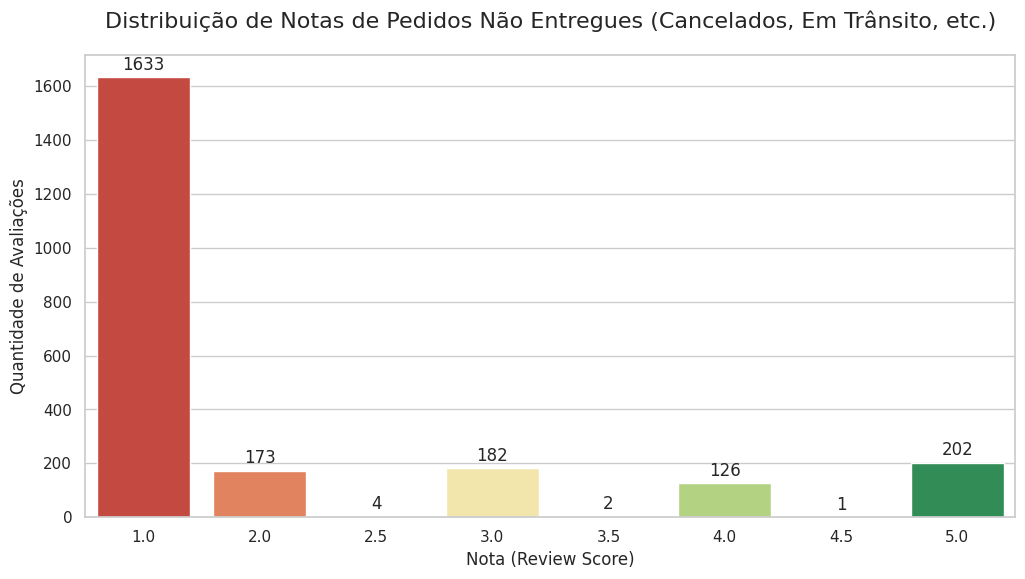

Satisfação Média para pedidos não entregues: 1.75


In [47]:
# Identificando o status atual de todos os pedidos no dataframe consolidado
df_status_nao_entregues = pd.merge(
    df_consolidado[['order_id', 'review_score']],
    df_orders[['order_id', 'order_status']],
    on='order_id',
    how='left'
)

# Filtrando apenas pedidos que NÃO estão como 'delivered'
df_nao_entregues = df_status_nao_entregues[df_status_nao_entregues['order_status'] != 'delivered']

# Plotando a distribuição de notas
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df_nao_entregues, x='review_score', palette='RdYlGn')

# Adicionando rótulos de contagem
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Distribuição de Notas de Pedidos Não Entregues (Cancelados, Em Trânsito, etc.)', fontsize=16, pad=20)
plt.xlabel('Nota (Review Score)')
plt.ylabel('Quantidade de Avaliações')
plt.show()

# Exibindo a média de satisfação desse grupo
media_nao_entregue = df_nao_entregues['review_score'].mean()
print(f"Satisfação Média para pedidos não entregues: {media_nao_entregue:.2f}")

É possível verificar através do gráfico que a grande maioria possui notas negativas (nota 1), sendo que a média geral para satisfação é 1,75.

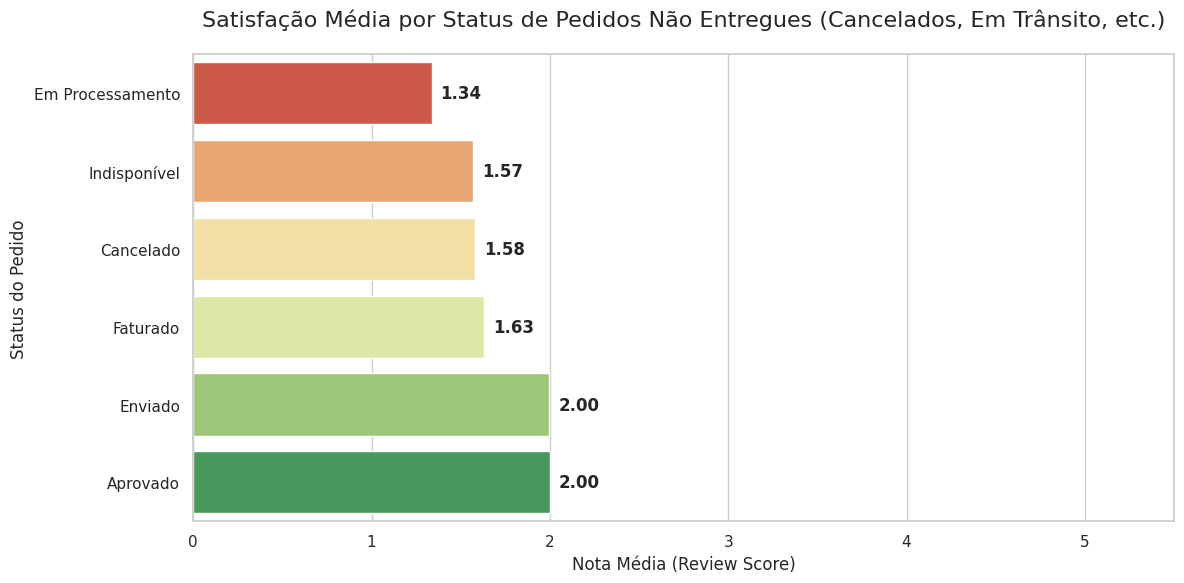

In [48]:
# Dicionário de tradução para os status
traducao_status = {
    'shipped': 'Enviado',
    'canceled': 'Cancelado',
    'processing': 'Em Processamento',
    'invoiced': 'Faturado',
    'unavailable': 'Indisponível',
    'approved': 'Aprovado'
}

# Agrupando a satisfação média por status (excluindo 'delivered')
satisfacao_por_status = df_status_nao_entregues[df_status_nao_entregues['order_status'] != 'delivered'].groupby('order_status')['review_score'].mean().sort_values().reset_index()

# Aplicando a tradução aos nomes dos status
satisfacao_por_status['order_status_pt'] = satisfacao_por_status['order_status'].map(traducao_status).fillna(satisfacao_por_status['order_status'])

# Criando o gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

grafico_status = sns.barplot(
    data=satisfacao_por_status,
    x='review_score',
    y='order_status_pt',
    hue='order_status_pt',
    palette='RdYlGn',
    legend=False
)

# Adicionando rótulos com a média
for i, valor in enumerate(satisfacao_por_status['review_score']):
    plt.text(valor + 0.05, i, f'{valor:.2f}', va='center', fontweight='bold')

plt.title('Satisfação Média por Status de Pedidos Não Entregues (Cancelados, Em Trânsito, etc.)', fontsize=16, pad=20)
plt.xlabel('Nota Média (Review Score)')
plt.ylabel('Status do Pedido')
plt.xlim(0, 5.5)

plt.tight_layout()
plt.show()

O gráfico acima mostra a satisfação média por status não entregue. Abaixo o número de pedidos, por status não entregue, que foram avaliados.

In [49]:
# Filtrando apenas os status que NÃO são 'delivered'
df_falhas = df_status_nao_entregues[df_status_nao_entregues['order_status'] != 'delivered'].copy()

# Ordenando por média de satisfação para organizar o gráfico
ordem_falhas = df_falhas.groupby('order_status')['review_score'].mean().sort_values().index

# Exibindo contagem para contexto
print("Quantidade de avaliações por status analisado:")
print(df_falhas['order_status'].value_counts())

Quantidade de avaliações por status analisado:
order_status
shipped        1090
canceled        524
processing      350
invoiced        349
unavailable       7
approved          3
Name: count, dtype: int64


O que pode ter ocorrido:
1. A pesquisa de satisfação é encaminhada ao cliente com base no tempo previsto para entrega e não no status real da entreta.
2. O pedido foi entregue, porém há um mismatch no status real e o status de sistema.

## Relação Tempo de Entrega X Satisfação

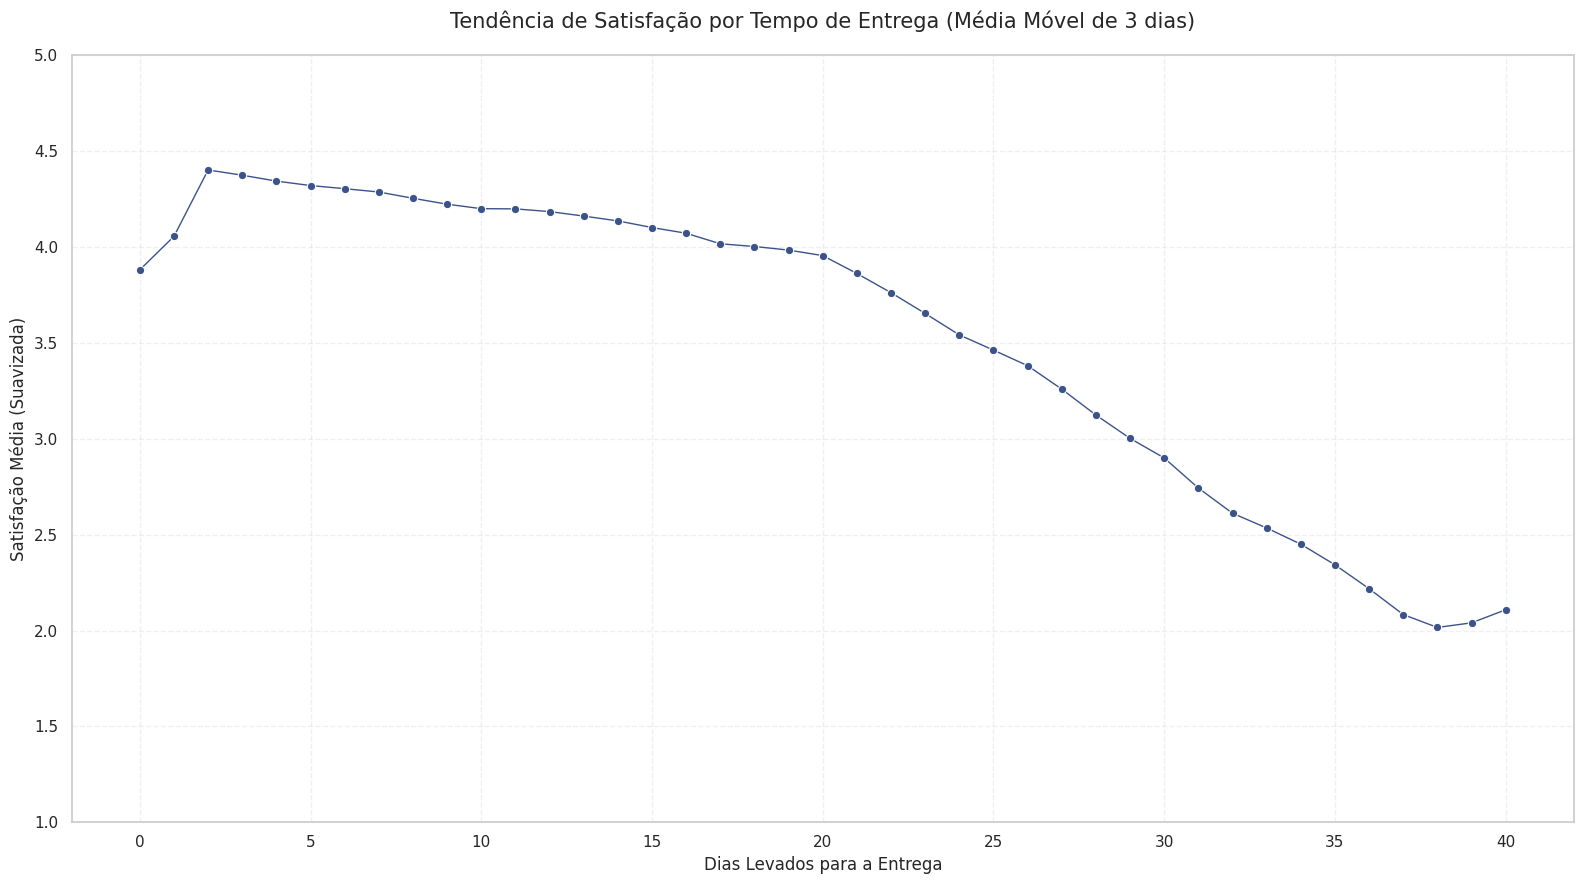

In [50]:

# Preparando os dados: Média por dia (até 40 dias para foco no que importa)
df_curva = df_consolidado[df_consolidado['tempo_entrega'] <= 40].groupby('tempo_entrega')['review_score'].mean().reset_index()

# Aplicando a Média Móvel (Rolling Mean)
# window=3 significa que cada ponto no gráfico será a média dele + os 2 dias vizinhos
# min_periods=1 garante que os primeiros dias também apareçam no gráfico
df_curva['review_score_suavizada'] = df_curva['review_score'].rolling(window=3, min_periods=1, center=True).mean()

# Criando o gráfico
plt.figure(figsize=(16, 9))

# Plotamos a linha suavizada (mais grossa e verde para indicar estabilidade/tendência)
sns.lineplot(data=df_curva, x='tempo_entrega', y='review_score_suavizada', marker='o', color=cor_viridis_azul, linewidth=1)

# --- NORMALIZAÇÃO DOS NÚMEROS (Limpeza visual) ---
# Eixo X: Dias inteiros de 0 a 40, pulando de 5 em 5
plt.xticks(np.arange(0, 41, 5))

# Eixo Y: Notas limpas de 1 a 5, com saltos de 0.5
plt.yticks(np.arange(1, 5.5, 0.5))

# Estética Final (Design)
plt.title('Tendência de Satisfação por Tempo de Entrega (Média Móvel de 3 dias)', fontsize=15, pad=20)
plt.xlabel('Dias Levados para a Entrega', fontsize=12)
plt.ylabel('Satisfação Média (Suavizada)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

O gráfico acima mostra a tendência de queda da avaliação conforme o tempo de entrega. É possível ver que entre os dias 15 e 20 a nota começa a cair abaixo de 4. Ou seja, torna-se interessante buscar que o tempo de entrega chegue idealmente a até 15 dias e, no máximo, 17 dias.

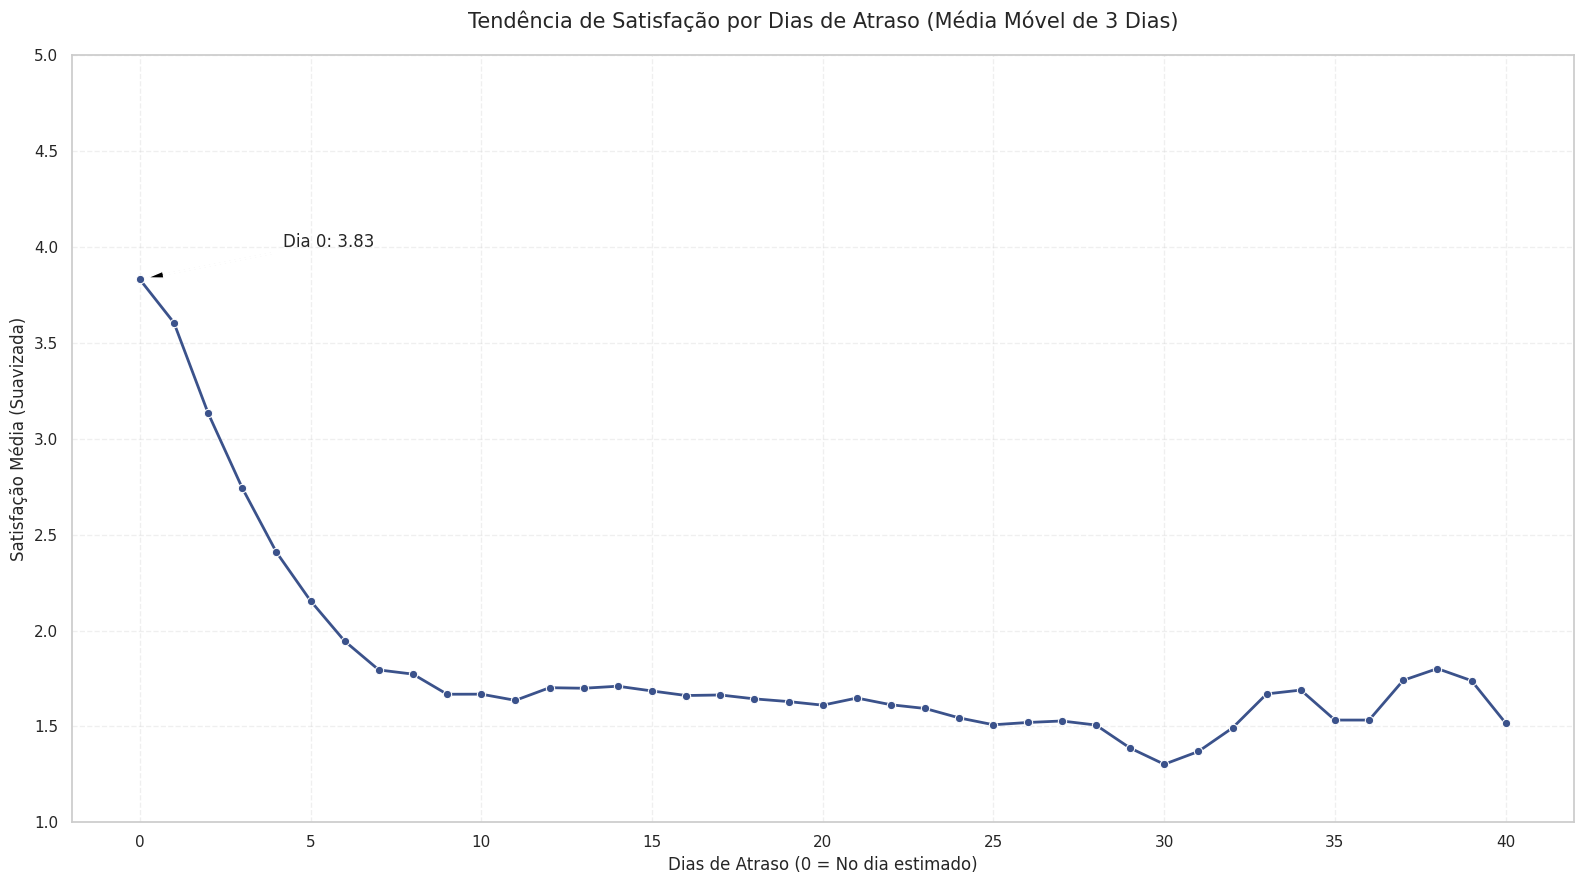

In [51]:
# Preparando os dados: Incluindo dia 0 (no prazo) e atrasos (até 40 dias)
df_curva_atraso = df_consolidado[(df_consolidado['atraso_dias'] >= 0) & (df_consolidado['atraso_dias'] <= 40)].copy()
df_agrupado_atraso = df_curva_atraso.groupby('atraso_dias')['review_score'].mean().reset_index()

# Aplicando a Média Móvel (Rolling Mean) de 3 dias para suavizar a tendência
df_agrupado_atraso['review_score_suavizada'] = df_agrupado_atraso['review_score'].rolling(window=3, min_periods=1, center=True).mean()

# ACriando o gráfico
plt.figure(figsize=(16, 9))

# Plotamos a linha de tendência usando a cor padrão definida anteriormente
sns.lineplot(data=df_agrupado_atraso, x='atraso_dias', y='review_score_suavizada', marker='o', color=cor_viridis_azul, linewidth=2)

# Ajustes de eixos para legibilidade
plt.xticks(np.arange(0, 41, 5))
plt.yticks(np.arange(1, 5.5, 0.5))

# Estética e Títulos
plt.title('Tendência de Satisfação por Dias de Atraso (Média Móvel de 3 Dias)', fontsize=15, pad=20)
plt.xlabel('Dias de Atraso (0 = No dia estimado)', fontsize=12)
plt.ylabel('Satisfação Média (Suavizada)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Adicionando uma anotação para destacar o ponto inicial
valor_inicial = df_agrupado_atraso.loc[df_agrupado_atraso['atraso_dias'] == 0, 'review_score_suavizada'].values[0]
plt.annotate(f'Dia 0: {valor_inicial:.2f}', xy=(0, valor_inicial), xytext=(4.2, 4),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

In [52]:
# Cálculo da queda de satisfação com base na média móvel
# Consideramos o 'atraso_dias' onde 0 é a entrega no prazo/estimada

# Agrupando e aplicando a média móvel de 3 dias
df_atraso_stats = df_consolidado[(df_consolidado['atraso_dias'] >= 0)].groupby('atraso_dias')['review_score'].mean().reset_index()
df_atraso_stats['review_score_suavizada'] = df_atraso_stats['review_score'].rolling(window=3, min_periods=1, center=True).mean()

# Obtendo os valores específicos
nota_dia_0 = df_atraso_stats.loc[df_atraso_stats['atraso_dias'] == 0, 'review_score_suavizada'].values[0]
nota_atraso_7 = df_atraso_stats.loc[df_atraso_stats['atraso_dias'] == 7, 'review_score_suavizada'].values[0]

# Calculando a porcentagem de queda
porcentagem_queda = ((nota_dia_0 - nota_atraso_7) / nota_dia_0) * 100

print(f"Satisfação Suavizada (Dia 0 - No Prazo): {nota_dia_0:.2f}")
print(f"Satisfação Suavizada (7 Dias de Atraso): {nota_atraso_7:.2f}")
print(f"Porcentagem de queda na avaliação: {porcentagem_queda:.2f}%")

Satisfação Suavizada (Dia 0 - No Prazo): 3.83
Satisfação Suavizada (7 Dias de Atraso): 1.79
Porcentagem de queda na avaliação: 53.17%


O gráfico acima analisa apenas os pedidos que chegaram na data máxima de entrega ou atrasados.

É possível ver que nos primeiros 7 dias de atraso os pedidos sofrem uma queda drástica na avaliação, uma queda de 2 pontos (57.17% da nota de pedidos que chegam no dia).

In [53]:
# Calculando a média e a mediana de dias previstos para entrega (Estimativa vs Compra)
dias_estimados = (df_consolidado['order_estimated_delivery_date'] - df_consolidado['order_purchase_timestamp']).dt.days
dias_estimados_media = dias_estimados.mean()
dias_estimados_mediana = dias_estimados.median()

print(f"A média de dias estimados para a entrega a partir da compra é de: {dias_estimados_media:.2f} dias.")
print(f"A mediana de dias estimados para a entrega a partir da compra é de: {dias_estimados_mediana:.2f} dias.")

A média de dias estimados para a entrega a partir da compra é de: 23.46 dias.
A mediana de dias estimados para a entrega a partir da compra é de: 23.00 dias.


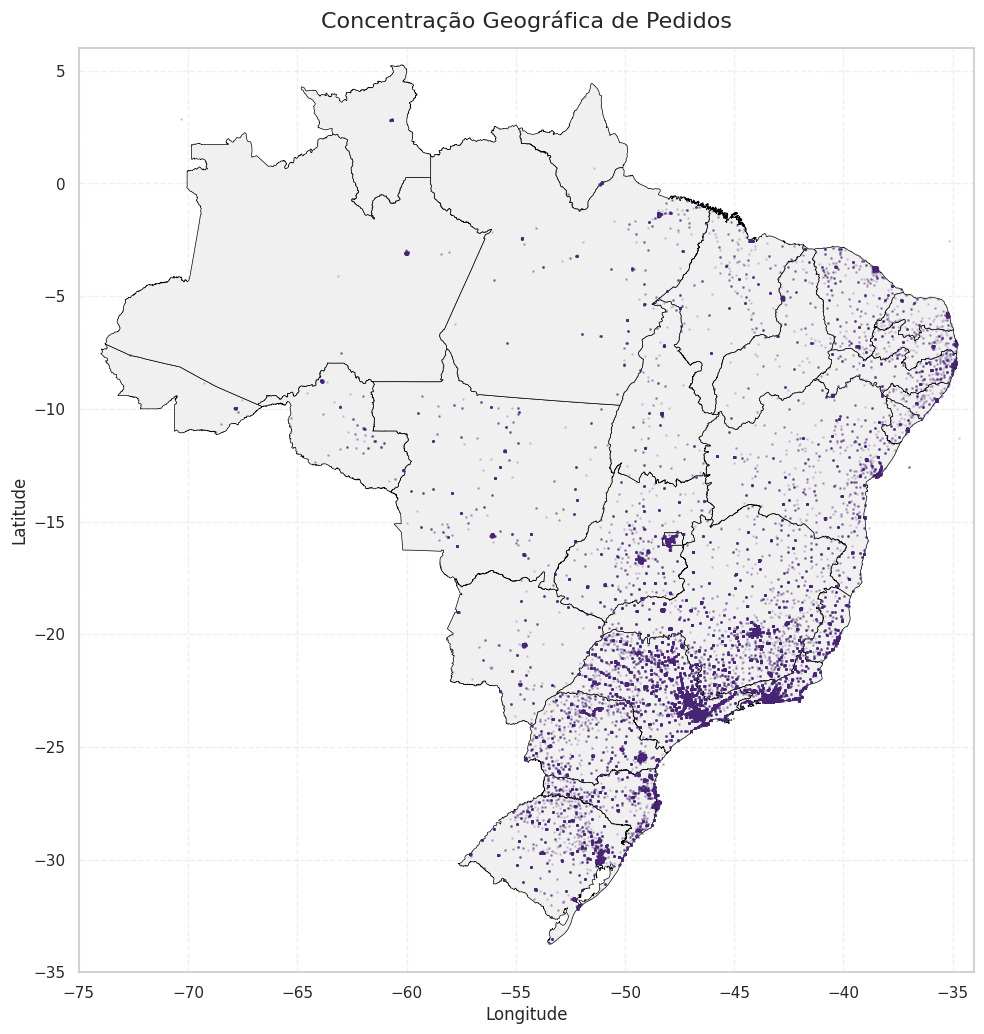

In [54]:
import geopandas as gpd

# Ensure df_consolidado has 'customer_id' by merging with df_orders
# Check if 'customer_id' is already in df_consolidado to avoid re-merging if already present
if 'customer_id' not in df_consolidado.columns:
    df_consolidado = pd.merge(df_consolidado, df_orders[['order_id', 'customer_id']], on='order_id', how='left')

# 1. Preparar a base de geolocalização
geo_coords = df_geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# 2. Unir com a base de clientes para pegar as coordenadas de cada pedido
df_geo_pedidos = pd.merge(df_consolidado, df_customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left')
df_geo_pedidos = pd.merge(df_geo_pedidos, geo_coords, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

# 3. Baixar o contorno do Brasil para servir de fundo
url_mapa = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
brazil_outline = gpd.read_file(url_mapa)

# 4. Plotagem
fig, ax = plt.subplots(figsize=(15, 12))

# Plotando o contorno do Brasil
brazil_outline.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=0.5)

# Obtendo uma cor representativa da paleta viridis (azul/roxo profundo)
cor_focal = plt.cm.viridis(0.1)

# Plotar os pontos de cada pedido focado na concentração (sem escala de preço)
ax.scatter(
    df_geo_pedidos['geolocation_lng'],
    df_geo_pedidos['geolocation_lat'],
    color=cor_focal,
    s=1,
    alpha=0.15
)

# Ajustando os limites para 'zoom' no Brasil
ax.set_xlim([-75, -34])
ax.set_ylim([-35, 6])

plt.title('Concentração Geográfica de Pedidos', fontsize=16, pad=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [55]:
import geopandas as gpd

# 1. Tabela de Vendas por Estado (Origem do Vendedor)
# Precisamos trazer o estado do vendedor para o df_consolidado
df_vendas_estado = pd.merge(
    df_consolidado[['order_id', 'seller_id']],
    df_sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

vendas_por_estado = df_vendas_estado.groupby('seller_state')['order_id'].nunique().sort_values(ascending=False).reset_index()
vendas_por_estado.columns = ['Estado do Vendedor', 'Total de Vendas (Pedidos)']

print("Tabela 1: Total de Vendas por Estado do Vendedor")
display(vendas_por_estado)

print("\n" + "="*50 + "\n")

# Add customer_state to df_consolidado if not already present
# This ensures the 'customer_state' column exists for the next step
if 'customer_state' not in df_consolidado.columns:
    df_consolidado = pd.merge(
        df_consolidado,
        df_customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )

# 2. Tabela de Compras por Estado (Destino do Cliente)
compras_por_estado = df_consolidado.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False).reset_index()
compras_por_estado.columns = ['Estado do Cliente', 'Total de Compras (Pedidos)']

print("Tabela 2: Total de Compras por Estado do Cliente")
display(compras_por_estado)


Tabela 1: Total de Vendas por Estado do Vendedor


,Estado do Vendedor,Total de Vendas (Pedidos)
0,SP,69176
1,MG,7854
2,PR,7502
3,RJ,4313
4,SC,3603
5,RS,1934
6,DF,822
7,BA,567
8,GO,460
9,PE,403




Tabela 2: Total de Compras por Estado do Cliente


,Estado do Cliente,Total de Compras (Pedidos)
0,SP,40811
1,RJ,12520
2,MG,11408
3,RS,5365
4,PR,4938
5,SC,3555
6,BA,3308
7,DF,2105
8,ES,1987
9,GO,1977


### Análise do Mapa Geográfico
O mapa confirma visualmente a dominância do estado de **São Paulo (SP)** e da região Sudeste no volume de transações da Olist.

Para tornar a análise ainda mais profunda em relação à logística, podemos gerar um mapa similar focado no **Tempo Médio de Entrega** ou na **Taxa de Atraso**, o que evidenciaria os gargalos nas regiões Norte e Nordeste citados anteriormente.

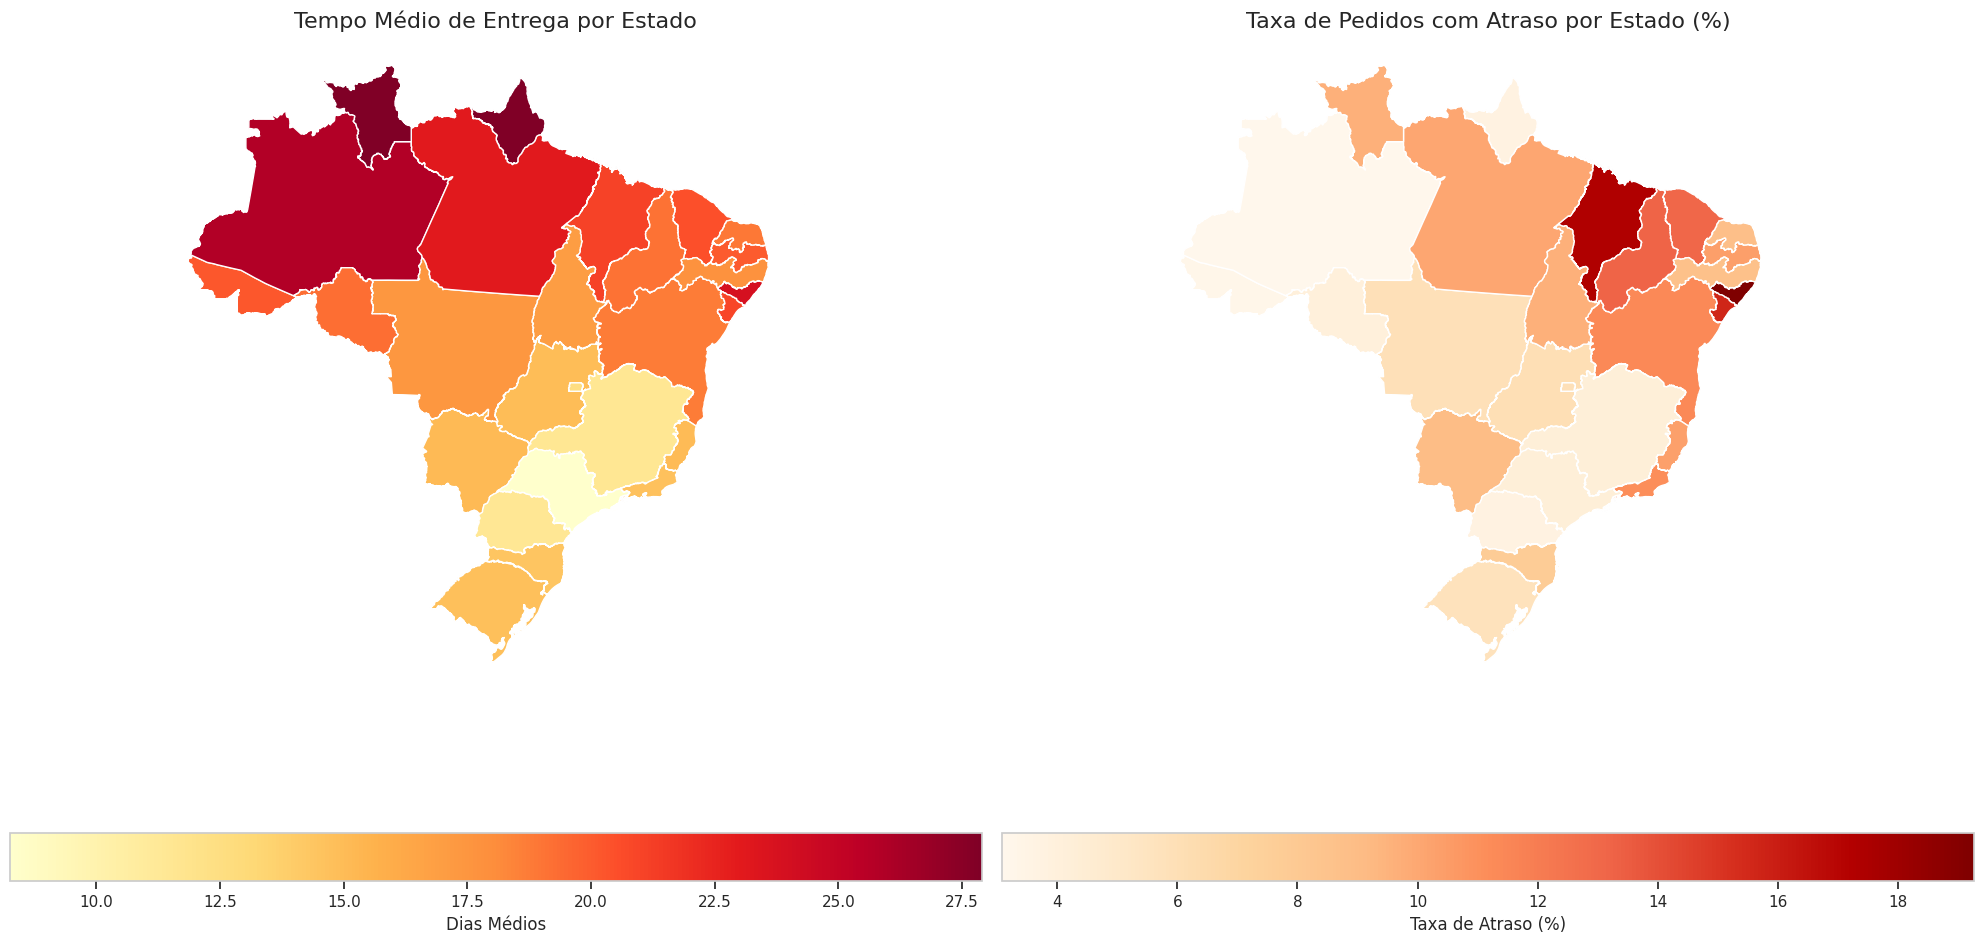

In [56]:
# Primeiro, precisamos trazer a informação do estado para o dataframe consolidado
if 'customer_state' not in df_consolidado.columns:
    df_consolidado = pd.merge(
        df_consolidado,
        df_customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )

# Calculando métricas logísticas por estado
logistica_estado = df_consolidado.groupby('customer_state').agg({
    'tempo_entrega': 'mean',
    'houve_atraso': 'mean'
}).reset_index()

# Convertendo a taxa de atraso para porcentagem
logistica_estado['taxa_atraso_perc'] = logistica_estado['houve_atraso'] * 100

# Unindo com o mapa (brazil_map foi definido anteriormente ou via GeoJSON)
# Usando brazil_outline carregado anteriormente se brazil_map não estiver no kernel
if 'brazil_map' not in locals():
    url_mapa = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
    brazil_map = gpd.read_file(url_mapa)

brazil_logistica = brazil_map.merge(logistica_estado, left_on='sigla', right_on='customer_state', how='left')

# Plotando os dois mapas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Tempo de Entrega
brazil_logistica.plot(column='tempo_entrega', cmap='YlOrRd', legend=True, ax=ax1,
                      legend_kwds={'label': "Dias Médios", 'orientation': "horizontal"})
ax1.set_title('Tempo Médio de Entrega por Estado', fontsize=16)
ax1.set_axis_off()

# Mapa 2: Taxa de Atraso (%)
brazil_logistica.plot(column='taxa_atraso_perc', cmap='OrRd', legend=True, ax=ax2,
                      legend_kwds={'label': "Taxa de Atraso (%)", 'orientation': "horizontal"})
ax2.set_title('Taxa de Pedidos com Atraso por Estado (%)', fontsize=16)
ax2.set_axis_off()

plt.tight_layout()
plt.show()

In [57]:
import pandas as pd

# 1. Agregando as métricas de tempo de entrega e atraso por estado
ranking_logistica = df_consolidado.groupby('customer_state').agg({
    'tempo_entrega': ['mean', 'median'],
    'atraso_dias': ['mean', 'median']
}).reset_index()

# 2. Renomeando as colunas para facilitar a leitura
ranking_logistica.columns = [
    'Estado',
    'Tempo Médio (Dias)',
    'Tempo Mediano (Dias)',
    'Atraso Médio (Dias)',
    'Atraso Mediano (Dias)'
]

# 3. Ordenando pelo Tempo Médio (do mais rápido para o mais lento)
ranking_logistica = ranking_logistica.sort_values(by='Tempo Médio (Dias)').reset_index(drop=True)

# 4. Exibindo a tabela formatada
print("Ranking Logístico por Estado (Ordenado por Tempo de Entrega)")
display(ranking_logistica.style.format({
    'Tempo Médio (Dias)': '{:.2f}',
    'Tempo Mediano (Dias)': '{:.1f}',
    'Atraso Médio (Dias)': '{:.2f}',
    'Atraso Mediano (Dias)': '{:.1f}'
}))

Ranking Logístico por Estado (Ordenado por Tempo de Entrega)


,Estado,Tempo Médio (Dias),Tempo Mediano (Dias),Atraso Médio (Dias),Atraso Mediano (Dias)
0,SP,8.25,7.0,-11.22,-11.0
1,PR,11.46,10.0,-13.53,-14.0
2,MG,11.49,10.0,-13.36,-14.0
3,DF,12.50,11.0,-12.18,-13.0
4,SC,14.43,12.0,-11.67,-13.0
5,RJ,14.63,11.0,-12.06,-13.0
6,RS,14.71,13.0,-14.13,-15.0
7,GO,14.96,13.0,-12.28,-13.0
8,ES,15.05,13.0,-10.80,-12.0
9,MS,15.11,13.0,-11.14,-13.0


### Diagnóstico Logístico Regional
Ao comparar os mapas, observamos que:
1. **Desigualdade de Prazos:** Existe uma disparidade clara entre o Sul/Sudeste e o restante do país. Enquanto estados como SP e PR possuem entregas rápidas, estados do Norte chegam a dobrar ou triplicar esse tempo.
2. **Gargalos de Eficiência:** A taxa de atraso não segue exatamente o mesmo padrão do volume de vendas, sugerindo que certas rotas de longa distância não apenas são demoradas por natureza, mas também são mais propensas a falhas no cumprimento do prazo estimado.

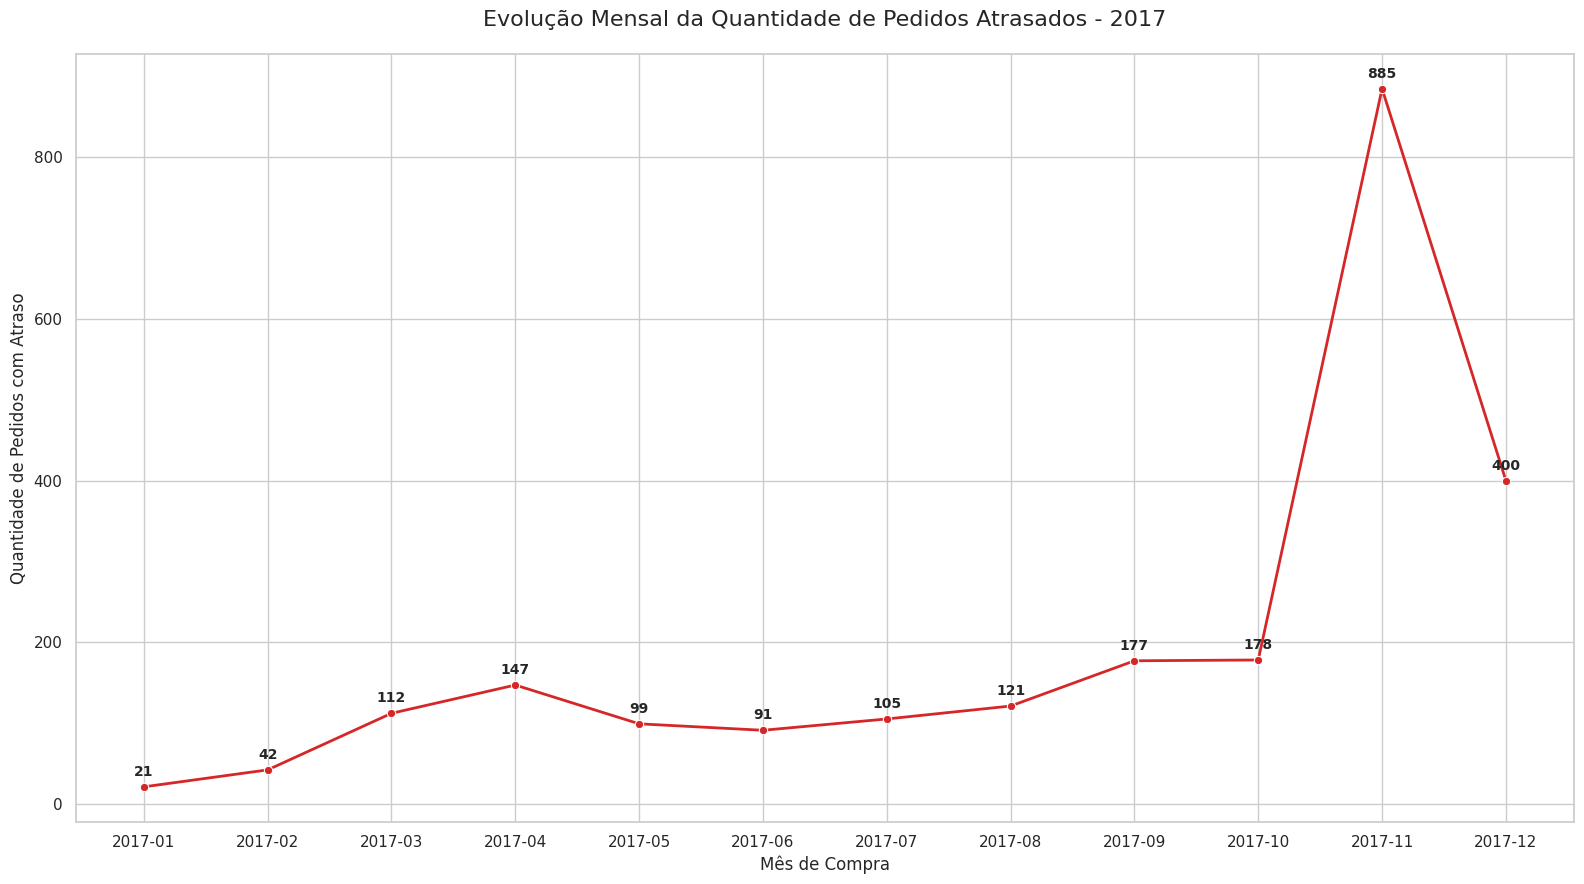

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Filtrando apenas os pedidos que tiveram atraso no ano de 2017
df_atrasados_2017 = df_consolidado[(df_consolidado['houve_atraso'] == True) &
                                   (df_consolidado['order_purchase_timestamp'].dt.year == 2017)].copy()

# Criando a coluna de mês/ano para agrupamento
df_atrasados_2017['mes_ano'] = df_atrasados_2017['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupando por mês e contando o número único de pedidos (order_id)
evolucao_atrasos = df_atrasados_2017.groupby('mes_ano')['order_id'].nunique().reset_index()

# Plotagem
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Usando uma cor avermelhada para indicar atrasos/problemas
sns.lineplot(data=evolucao_atrasos, x='mes_ano', y='order_id', marker='o', color='#d62728', linewidth=2)

# Customização
plt.title('Evolução Mensal da Quantidade de Pedidos Atrasados - 2017', fontsize=16, pad=20)
plt.xlabel('Mês de Compra', fontsize=12)
plt.ylabel('Quantidade de Pedidos com Atraso', fontsize=12)

# Adicionando rótulos nos pontos para clareza
for x, y in zip(evolucao_atrasos['mes_ano'], evolucao_atrasos['order_id']):
    plt.text(x, y + 10, str(int(y)), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

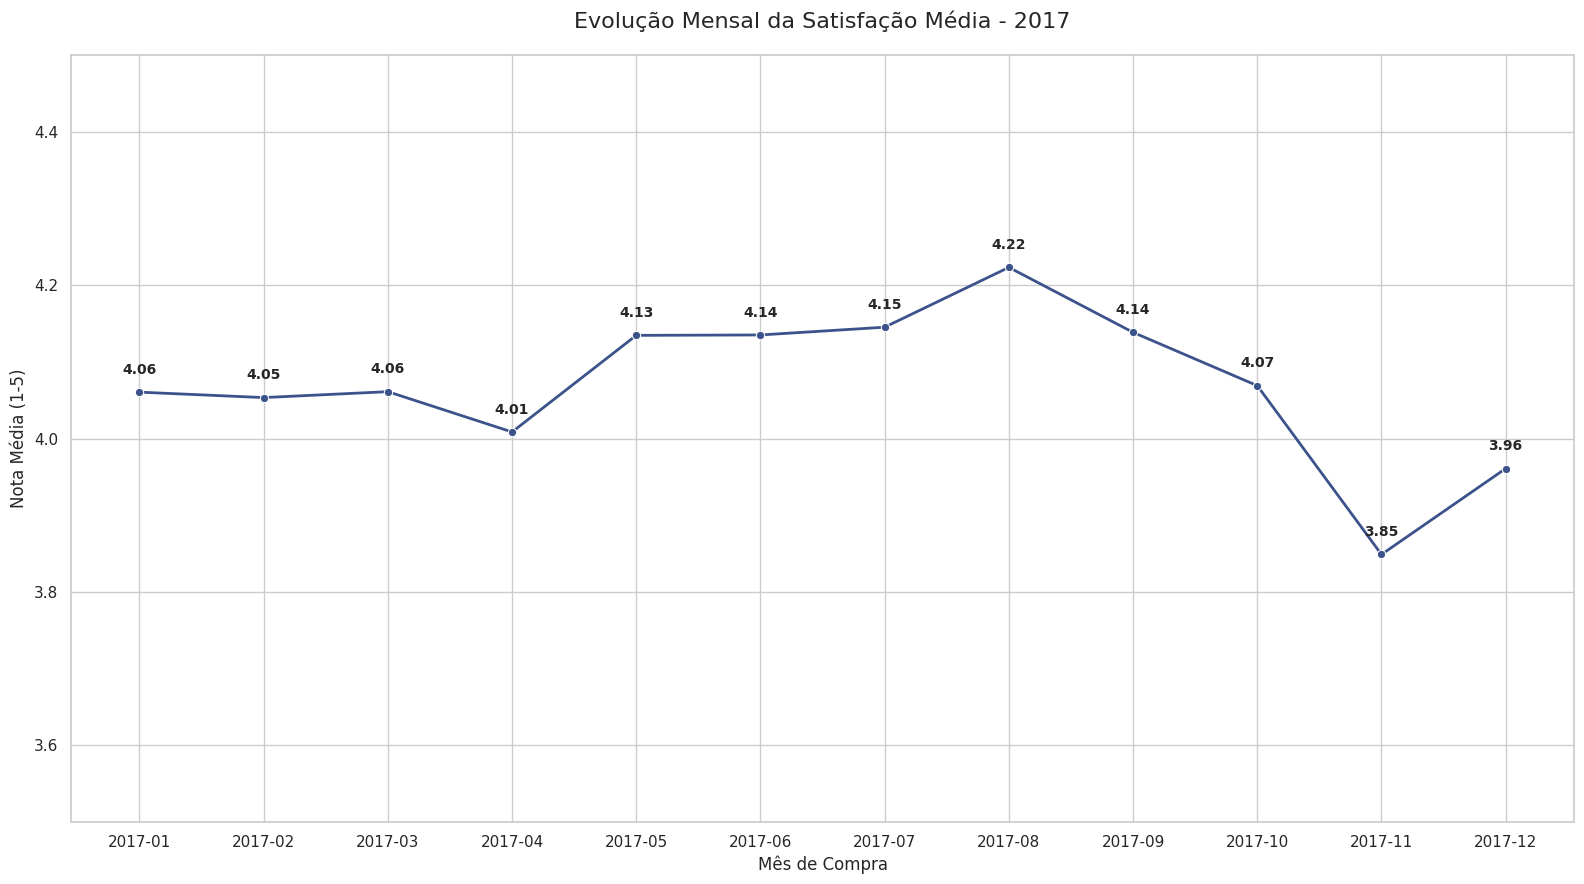

Tabela: Evolução da Nota Média por Mês (2017)


,Mês,Nota Média
0,2017-01,4.06
1,2017-02,4.05
2,2017-03,4.06
3,2017-04,4.01
4,2017-05,4.13
5,2017-06,4.14
6,2017-07,4.15
7,2017-08,4.22
8,2017-09,4.14
9,2017-10,4.07


In [59]:
# Recriando o df_2017 a partir do df_consolidado atualizado (que agora tem review_score)
mask_2017_atualizada = (df_consolidado['order_purchase_timestamp'] >= '2017-01-01') & (df_consolidado['order_purchase_timestamp'] <= '2017-12-31')
df_2017 = df_consolidado.loc[mask_2017_atualizada].copy()
df_2017['mes_ano'] = df_2017['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupando por mês e calculando a média da nota
evolucao_nota_2017 = df_2017.groupby('mes_ano')['review_score'].mean().reset_index()

# --- PARTE 1: Gráfico de Evolução ---
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

sns.lineplot(data=evolucao_nota_2017, x='mes_ano', y='review_score', marker='o', color=cor_viridis_azul, linewidth=2)

plt.title('Evolução Mensal da Satisfação Média - 2017', fontsize=16, pad=20)
plt.xlabel('Mês de Compra', fontsize=12)
plt.ylabel('Nota Média (1-5)', fontsize=12)
plt.ylim(3.5, 4.5)

for x, y in zip(evolucao_nota_2017['mes_ano'], evolucao_nota_2017['review_score']):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --- PARTE 2: Tabela de Dados ---
print("Tabela: Evolução da Nota Média por Mês (2017)")
display(evolucao_nota_2017.rename(columns={'mes_ano': 'Mês', 'review_score': 'Nota Média'}).style.format({'Nota Média': '{:.2f}'}))

## Consolidado do número de notas.

/tmp/ipykernel_34255/2319336047.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_reviews, x='review_score', palette='RdYlGn')


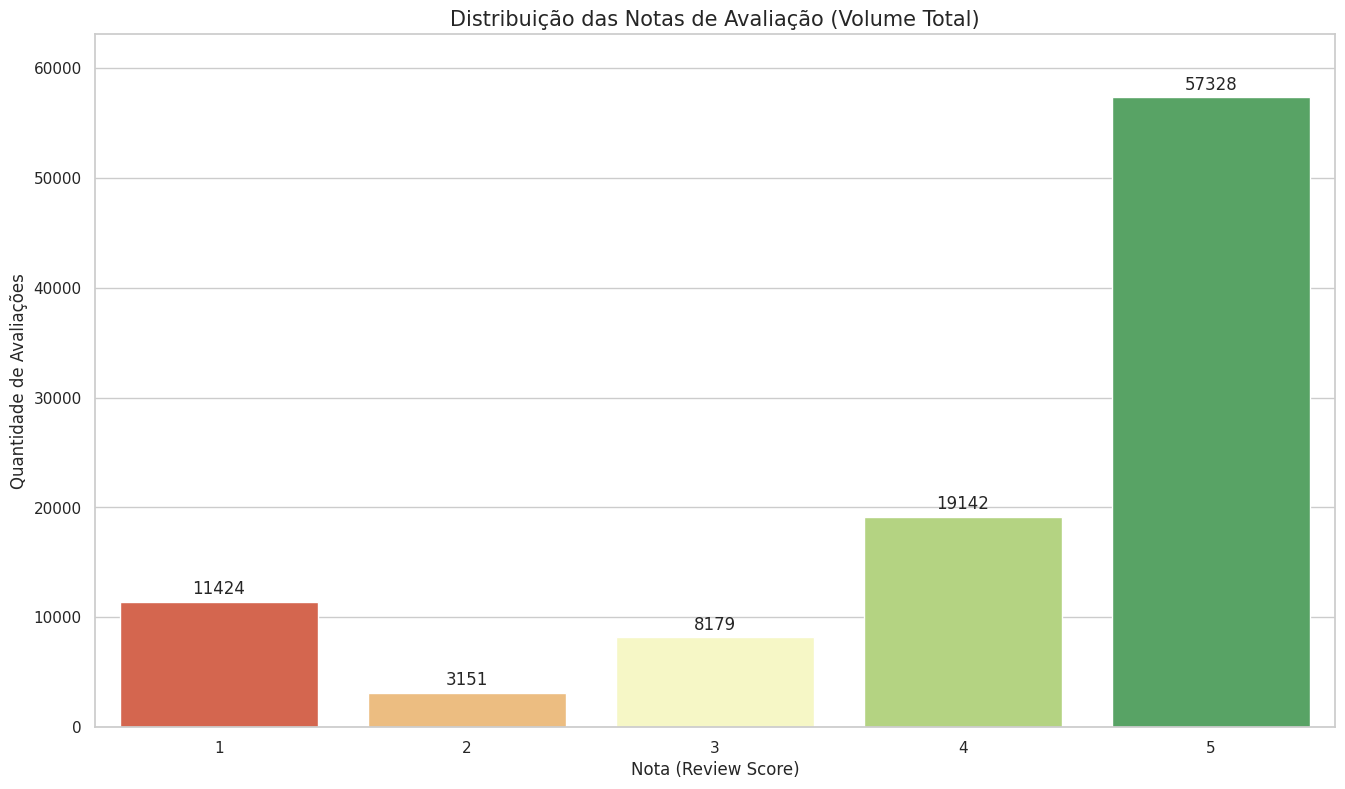

In [60]:
# Usando o DataFrame de reviews originais ou o seu consolidado
plt.figure(figsize=(16, 9))

ax = sns.countplot(data=df_reviews, x='review_score', palette='RdYlGn')

# Adicionando os valores em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Distribuição das Notas de Avaliação (Volume Total)', fontsize=15)
plt.xlabel('Nota (Review Score)', fontsize=12)
plt.ylabel('Quantidade de Avaliações', fontsize=12)
plt.ylim(0, df_reviews['review_score'].value_counts().max() * 1.1) # Espaço para o texto acima
plt.show()

In [61]:
# Filtrando o dataset para o ano de 2017
df_2017_csat = df_consolidado[df_consolidado['order_purchase_timestamp'].dt.year == 2017].copy()

# 1. Cálculo do CSAT por Categoria (Apenas 2017)
def calcular_csat(scores):
    return (scores >= 4).sum() / len(scores) * 100

csat_categorias_2017 = df_2017_csat.groupby('product_category_name')['review_score'].apply(calcular_csat).sort_values(ascending=False).reset_index()
csat_categorias_2017.columns = ['Categoria', 'CSAT (%)']

print("--- CSAT por Categoria (Ano 2017) ---")
display(csat_categorias_2017.style.format({'CSAT (%)': '{:.2f}%'}))

# 2. Cálculo da Variação Mensal do CSAT em 2017
evolucao_csat_2017 = df_2017_csat.groupby('ano_mes')['review_score'].apply(calcular_csat).reset_index()
evolucao_csat_2017.columns = ['Mês', 'CSAT (%)']

# Calculando a variação (diferença em pontos percentuais entre meses)
evolucao_csat_2017['Variação (p.p.)'] = evolucao_csat_2017['CSAT (%)'].diff()

print("\n--- Evolução e Variação Mensal do CSAT em 2017 ---")
display(evolucao_csat_2017.style.format({
    'CSAT (%)': '{:.2f}%',
    'Variação (p.p.)': '{:+.2f}'
}))

--- CSAT por Categoria (Ano 2017) ---


,Categoria,CSAT (%)
0,"Livros, Jornais e Papelaria",80.80%
1,Alimentos e Bebidas,80.06%
2,Outros Artigos de Uso Pessoal e Doméstico,79.05%
3,Saúde e Beleza,78.11%
4,"Veículos, Motocicletas e Peças",75.65%
5,Material de Construção,75.32%
6,Equipamentos de Informática e Comunicação,75.21%
7,"Tecidos, Vestuário e Calçados",73.51%
8,Móveis e Eletrodomésticos,72.53%
9,Não Informado,72.25%



--- Evolução e Variação Mensal do CSAT em 2017 ---


,Mês,CSAT (%),Variação (p.p.)
0,2017-01,75.70%,+nan
1,2017-02,75.29%,-0.41
2,2017-03,76.23%,+0.94
3,2017-04,74.48%,-1.75
4,2017-05,78.29%,+3.81
5,2017-06,78.18%,-0.11
6,2017-07,78.20%,+0.02
7,2017-08,81.21%,+3.00
8,2017-09,78.66%,-2.54
9,2017-10,76.70%,-1.96


### Investigando os casos 'not_defined'
Vamos verificar os detalhes dos pedidos que possuem o tipo de pagamento como não definido.

In [62]:
# Filtrando os casos de pagamento não definido
pagamentos_not_defined = df_payments[df_payments['payment_type'] == 'not_defined']

# Cruzando com a tabela de pedidos para ver o status dessas ordens
detalhes_not_defined = pd.merge(
    pagamentos_not_defined,
    df_orders[['order_id', 'order_status', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

display(detalhes_not_defined)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status,order_purchase_timestamp
0,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0,canceled,2018-09-03 14:14:25
1,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0,canceled,2018-08-28 15:26:39
2,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0,canceled,2018-08-28 20:05:14
